# CogAge All-Subject Dataset and Optimizer Comparison

This notebook loads the separately prepared subject datasets, displays their shapes, class counts, metadata, and sample sensor values, then performs the four-class optimizer assignment for subjects with all four activities in both original splits.

**Run from the workspace root** after running `python DATA_PREP/prepare_all_subjects.py`. The prepared files are read from the newest `DATA_PREP/processed_datasets_by_subject/run_*` folder. This notebook writes experiment results to a new `DATA_PREP/all_subjects_experiments/run_*` folder and does not replace the prepared datasets.

Tested dependencies: Python 3.12, NumPy, pandas, Matplotlib, scikit-learn, and joblib. Install with `python -m pip install numpy pandas matplotlib scikit-learn joblib jupyter ipykernel`.

**Data availability:** The four labels remain Bending=0, Walking=1, Sitting=2, Standing=3. In the inspected data, S1, S2, S5, and S7 have paired folders for all four classes. S3, S6, and S8 have only partial class sets, so they are displayed but excluded from four-class optimizer comparisons. S4 has no original `_2_extracted` folders and is skipped. This notebook preserves each subject’s `_1_extracted` train and `_2_extracted` test folders; validation Events are selected only from `_1_extracted`. Results from single-subject datasets are small and should not be presented as participant-independent generalization.

In [3]:
from pathlib import Path
from collections import Counter
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler

current_directory = Path.cwd().resolve()
DATA_PREP_DIR = None
for candidate in (current_directory, *current_directory.parents):
    if candidate.name.lower() == 'data_prep' and (candidate / 'processed_datasets_by_subject').is_dir():
        DATA_PREP_DIR = candidate
        break
    nested_data_prep = candidate / 'DATA_PREP'
    if (nested_data_prep / 'processed_datasets_by_subject').is_dir():
        DATA_PREP_DIR = nested_data_prep
        break
if DATA_PREP_DIR is None:
    raise FileNotFoundError(
        f'Could not locate DATA_PREP/processed_datasets_by_subject above {current_directory}'
    )
WORKSPACE = DATA_PREP_DIR.parent
PREPARED_ROOT = DATA_PREP_DIR / 'processed_datasets_by_subject'
run_folders = sorted(PREPARED_ROOT.glob('run_*'), key=lambda path: path.stat().st_mtime)
if not run_folders:
    raise FileNotFoundError('No prepared subject run found. Run prepare_all_subjects.py first.')
PREPARED_RUN = run_folders[-1]
SUBJECT_RUN_SUMMARY = pd.read_csv(PREPARED_RUN / 'subject_preparation_summary.csv')
CLASS_MAPPING = json.loads((PREPARED_RUN / 'class_mapping.json').read_text(encoding='utf-8'))
CLASS_NAMES = {label: name for name, label in CLASS_MAPPING.items()}
CLASS_IDS = np.array(sorted(CLASS_NAMES), dtype=np.int64)
SUBJECT_DATASETS = {}

print(f'DATA_PREP directory: {DATA_PREP_DIR}')
print(f'Prepared dataset run: {PREPARED_RUN}')
print('Preparation status by subject:')
display(SUBJECT_RUN_SUMMARY)
print('Folder-pair availability:')
display(pd.read_csv(PREPARED_RUN / 'subject_activity_inventory.csv'))

for _, row in SUBJECT_RUN_SUMMARY.iterrows():
    if row['status'] != 'prepared':
        continue
    subject = row['subject']
    folder = PREPARED_RUN / subject
    dataset = {
        'X_train': np.load(folder / 'X_train.npy'),
        'y_train': np.load(folder / 'y_train.npy'),
        'X_test': np.load(folder / 'X_test.npy'),
        'y_test': np.load(folder / 'y_test.npy'),
        'train_metadata': pd.read_csv(folder / 'train_metadata.csv'),
        'test_metadata': pd.read_csv(folder / 'test_metadata.csv'),
        'feature_names': json.loads((folder / 'feature_names.json').read_text(encoding='utf-8')),
        'class_mapping': json.loads((folder / 'class_mapping.json').read_text(encoding='utf-8')),
        'folder': folder,
    }
    SUBJECT_DATASETS[subject] = dataset
    print(f'\n{subject}: X_train={dataset["X_train"].shape}, y_train={dataset["y_train"].shape}, '
          f'X_test={dataset["X_test"].shape}, y_test={dataset["y_test"].shape}')
    print('Training label counts:', dict(Counter(dataset['y_train'].tolist())))
    print('Testing label counts: ', dict(Counter(dataset['y_test'].tolist())))

    train_head = dataset['train_metadata'][['activity', 'label', 'original_folder', 'event', 'window_id']].head(5).copy()
    for feature_index, feature_name in enumerate(dataset['feature_names'][:5]):
        train_head[feature_name] = dataset['X_train'][:5, 0, feature_index]
    print(f'{subject} training dataset head (first timestep, first five features):')
    display(train_head)
    print(f'{subject} available class mapping: {dataset["class_mapping"]}')

DATA_PREP directory: D:\7th sem\ML\DATASETS\Annonmazed_CogActivity\DATA_PREP
Prepared dataset run: D:\7th sem\ML\DATASETS\Annonmazed_CogActivity\DATA_PREP\processed_datasets_by_subject\run_20261003_101625
Preparation status by subject:


,subject,status,paired_activities,train_windows,test_windows,output_dir
0,S1,prepared,"Bending,Walking,Sitting,Standing",40,40,D:\7th sem\ML\DATASETS\Annonmazed_CogActivity\...
1,S2,prepared,"Bending,Walking,Sitting,Standing",40,40,D:\7th sem\ML\DATASETS\Annonmazed_CogActivity\...
2,S3,prepared,"Bending,Standing",20,20,D:\7th sem\ML\DATASETS\Annonmazed_CogActivity\...
3,S4,skipped_no_activity_with_both_splits,NaN,0,0,NaN
4,S5,prepared,"Bending,Walking,Sitting,Standing",40,40,D:\7th sem\ML\DATASETS\Annonmazed_CogActivity\...
5,S6,prepared,"Bending,Sitting,Standing",30,30,D:\7th sem\ML\DATASETS\Annonmazed_CogActivity\...
6,S7,prepared,"Bending,Walking,Sitting,Standing",38,39,D:\7th sem\ML\DATASETS\Annonmazed_CogActivity\...
7,S8,prepared,Bending,10,9,D:\7th sem\ML\DATASETS\Annonmazed_CogActivity\...


Folder-pair availability:


,subject,activity,train_folder,test_folder,status
0,S1,Bending,S1_Bending_1_extracted,S1_Bending_2_extracted,paired
1,S1,Walking,S1_Walking_1_extracted,S1_Walking_2_extracted,paired
2,S1,Sitting,S1_Sitting_1_extracted,S1_Sitting_2_extracted,paired
3,S1,Standing,S1_Standing_1_extracted,S1_Standing_2_extracted,paired
4,S2,Bending,S2_Bending_1_extracted,S2_Bending_2_extracted,paired
5,S2,Walking,S2_Walking_1_extracted,S2_Walking_2_extracted,paired
6,S2,Sitting,S2_Sitting_1_extracted,S2_Sitting_2_extracted,paired
7,S2,Standing,S2_Standing_1_extracted,S2_Standing_2_extracted,paired
8,S3,Bending,S3_Bending_1_extracted,S3_Bending_2_extracted,paired
9,S3,Walking,NaN,NaN,missing_both



S1: X_train=(40, 128, 33), y_train=(40,), X_test=(40, 128, 33), y_test=(40,)
Training label counts: {0: 10, 1: 10, 2: 10, 3: 10}
Testing label counts:  {0: 10, 1: 10, 2: 10, 3: 10}
S1 training dataset head (first timestep, first five features):


...

S6 available class mapping: {'Bending': 0, 'Walking': 1, 'Sitting': 2, 'Standing': 3}

S7: X_train=(38, 128, 33), y_train=(38,), X_test=(39, 128, 33), y_test=(39,)
Training label counts: {0: 10, 1: 10, 2: 8, 3: 10}
Testing label counts:  {0: 10, 1: 10, 2: 9, 3: 10}
S7 training dataset head (first timestep, first five features):


,activity,label,original_folder,event,window_id,android.sensor.accelerometer_value_1,android.sensor.accelerometer_value_2,android.sensor.accelerometer_value_3,android.sensor.gyroscope_value_1,android.sensor.gyroscope_value_2
0,Bending,0,S7_Bending_1_extracted,Event_0,0,-1.205348,1.136275,-0.161657,-1.001238,-0.160273
1,Bending,0,S7_Bending_1_extracted,Event_1,0,-1.247038,1.270810,0.325567,0.271675,-0.031534
2,Bending,0,S7_Bending_1_extracted,Event_2,0,-0.373002,1.839201,0.984349,0.510149,-0.829959
3,Bending,0,S7_Bending_1_extracted,Event_3,0,-1.200228,1.319731,0.561936,-1.429623,-0.615808
4,Bending,0,S7_Bending_1_extracted,Event_4,0,-0.614368,1.194853,0.706044,-0.072612,-0.468501


S7 available class mapping: {'Bending': 0, 'Walking': 1, 'Sitting': 2, 'Standing': 3}

S8: X_train=(10, 128, 33), y_train=(10,), X_test=(9, 128, 33), y_test=(9,)
Training label counts: {0: 10}
Testing label counts:  {0: 9}
S8 training dataset head (first timestep, first five features):


,activity,label,original_folder,event,window_id,android.sensor.accelerometer_value_1,android.sensor.accelerometer_value_2,android.sensor.accelerometer_value_3,android.sensor.gyroscope_value_1,android.sensor.gyroscope_value_2
0,Bending,0,S8_Bending_1_extracted,Event_0,0,0.774394,0.522043,-0.009987,0.658288,-0.333488
1,Bending,0,S8_Bending_1_extracted,Event_1,0,-1.150978,0.313244,0.441090,-0.049113,-2.213597
2,Bending,0,S8_Bending_1_extracted,Event_2,0,-0.985539,0.012186,0.532765,-0.560519,-2.039968
3,Bending,0,S8_Bending_1_extracted,Event_3,0,-0.547079,0.037852,-0.941346,0.601769,-1.150214
4,Bending,0,S8_Bending_1_extracted,Event_4,0,-0.331908,-0.562877,-0.191715,1.729720,0.268623


S8 available class mapping: {'Bending': 0, 'Walking': 1, 'Sitting': 2, 'Standing': 3}


In [4]:
VALIDATION_FRACTION = 0.20
RANDOM_SEED = 42
MODEL_DATA = {}
EXCLUDED_FROM_MODEL = []

for subject, dataset in SUBJECT_DATASETS.items():
    y_train_subject = dataset['y_train']
    y_test_subject = dataset['y_test']
    train_classes = set(np.unique(y_train_subject).tolist())
    test_classes = set(np.unique(y_test_subject).tolist())
    if train_classes != set(CLASS_IDS.tolist()) or test_classes != set(CLASS_IDS.tolist()):
        missing_train = sorted(set(CLASS_IDS.tolist()) - train_classes)
        missing_test = sorted(set(CLASS_IDS.tolist()) - test_classes)
        EXCLUDED_FROM_MODEL.append({
            'subject': subject,
            'reason': f'missing train labels {missing_train}; missing test labels {missing_test}',
        })
        continue

    train_metadata = dataset['train_metadata'].reset_index(drop=True)
    event_groups = (
        train_metadata['original_folder'].astype(str) + '::' + train_metadata['event'].astype(str)
    ).to_numpy()
    train_indices = []
    validation_indices = []
    subject_number = int(subject[1:])
    rng = np.random.default_rng(RANDOM_SEED + subject_number)
    for class_id in CLASS_IDS:
        class_indices = np.flatnonzero(y_train_subject == class_id)
        class_groups = np.unique(event_groups[class_indices])
        if len(class_groups) < 2:
            raise ValueError(f'{subject} class {class_id} has fewer than two training Events.')
        validation_group_count = max(1, int(round(len(class_groups) * VALIDATION_FRACTION)))
        validation_group_count = min(validation_group_count, len(class_groups) - 1)
        held_out_groups = rng.choice(class_groups, size=validation_group_count, replace=False)
        goes_to_validation = np.isin(event_groups[class_indices], held_out_groups)
        validation_indices.extend(class_indices[goes_to_validation].tolist())
        train_indices.extend(class_indices[~goes_to_validation].tolist())

    train_indices = np.array(sorted(train_indices), dtype=int)
    validation_indices = np.array(sorted(validation_indices), dtype=int)
    assert set(event_groups[train_indices]).isdisjoint(set(event_groups[validation_indices]))

    X_original_train = dataset['X_train']
    X_original_test = dataset['X_test']
    # The saved per-subject scaler is a per-feature affine transform. Fitting this second
    # scaler on the model-training subset algebraically removes its earlier statistics.
    model_scaler = StandardScaler()
    model_scaler.fit(X_original_train[train_indices].reshape(-1, X_original_train.shape[-1]))

    def transform_subject_windows(windows, fitted_scaler):
        if not len(windows):
            return windows.astype(np.float32, copy=True)
        flat = windows.reshape(-1, windows.shape[-1])
        return fitted_scaler.transform(flat).reshape(windows.shape).astype(np.float32)

    X_fit_subject = transform_subject_windows(X_original_train[train_indices], model_scaler)
    X_valid_subject = transform_subject_windows(X_original_train[validation_indices], model_scaler)
    X_test_subject = transform_subject_windows(X_original_test, model_scaler)
    subject_data = {
        'X_train': X_fit_subject.reshape(len(X_fit_subject), -1).astype(np.float64),
        'y_train': y_train_subject[train_indices].astype(np.int64),
        'X_validation': X_valid_subject.reshape(len(X_valid_subject), -1).astype(np.float64),
        'y_validation': y_train_subject[validation_indices].astype(np.int64),
        'X_test': X_test_subject.reshape(len(X_test_subject), -1).astype(np.float64),
        'y_test': y_test_subject.astype(np.int64),
        'scaler': model_scaler,
        'train_metadata': train_metadata.iloc[train_indices].reset_index(drop=True),
        'validation_metadata': train_metadata.iloc[validation_indices].reset_index(drop=True),
        'test_metadata': dataset['test_metadata'].reset_index(drop=True),
        'feature_names': dataset['feature_names'],
    }
    MODEL_DATA[subject] = subject_data
    assert subject_data['train_metadata']['original_folder'].str.endswith('_1_extracted').all()
    assert subject_data['validation_metadata']['original_folder'].str.endswith('_1_extracted').all()
    assert subject_data['test_metadata']['original_folder'].str.endswith('_2_extracted').all()

split_rows = []
for subject, data in MODEL_DATA.items():
    for class_id in CLASS_IDS:
        split_rows.append({
            'subject': subject,
            'activity': CLASS_NAMES[int(class_id)],
            'label': int(class_id),
            'model_train': int(np.sum(data['y_train'] == class_id)),
            'validation': int(np.sum(data['y_validation'] == class_id)),
            'held_out_test': int(np.sum(data['y_test'] == class_id)),
        })
SPLIT_COUNTS = pd.DataFrame(split_rows)
print('Four-class subjects eligible for optimizer runs:', sorted(MODEL_DATA))
print('Subjects excluded from 4-class experiments (still inspected above):')
display(pd.DataFrame(EXCLUDED_FROM_MODEL))
print('Event-grouped train/validation/test counts:')
display(SPLIT_COUNTS)
print('Limitation: each per-subject dataset has a single participant; this is not participant-independent evaluation.')

Four-class subjects eligible for optimizer runs: ['S1', 'S2', 'S5', 'S7']
Subjects excluded from 4-class experiments (still inspected above):


,subject,reason
0,S3,"missing train labels [1, 2]; missing test labe..."
1,S6,missing train labels [1]; missing test labels [1]
2,S8,"missing train labels [1, 2, 3]; missing test l..."


Event-grouped train/validation/test counts:


,subject,activity,label,model_train,validation,held_out_test
0,S1,Bending,0,8,2,10
1,S1,Walking,1,8,2,10
2,S1,Sitting,2,8,2,10
3,S1,Standing,3,8,2,10
4,S2,Bending,0,8,2,10
5,S2,Walking,1,8,2,10
6,S2,Sitting,2,8,2,10
7,S2,Standing,3,8,2,10
8,S5,Bending,0,8,2,10
9,S5,Walking,1,8,2,10


Limitation: each per-subject dataset has a single participant; this is not participant-independent evaluation.


## Fixed network and eight optimizers

The model uses a `4,224 -> 32 -> 16 -> 4` fully connected architecture with ReLU hidden layers and four raw logits (135,796 parameters). Loss is sparse categorical cross-entropy from logits. Each optimizer gets the same initialization, 100-epoch limit, base learning rate 0.01, mini-batch size 8, and data partitions. Test results use the best-validation-loss checkpoint; the original test set is not used for selection.

In [5]:
EXPERIMENT_SEED = 42
MAX_EPOCHS = 100
MINI_BATCH_SIZE = 8
LEARNING_RATE = 0.01
MOMENTUM = 0.9
ADAMW_WEIGHT_DECAY = 0.01
HIDDEN_DIMS = (32, 16)
OUTPUT_DIM = len(CLASS_IDS)
INPUT_DIM = next(iter(MODEL_DATA.values()))['X_train'].shape[1]
PARAMETER_COUNT = (INPUT_DIM + 1) * HIDDEN_DIMS[0] + (HIDDEN_DIMS[0] + 1) * HIDDEN_DIMS[1] + (HIDDEN_DIMS[1] + 1) * OUTPUT_DIM

OPTIMIZERS = [
    {'name': 'Full-batch GD', 'key': 'full_batch_gd', 'batch_size': None},
    {'name': 'Mini-batch GD', 'key': 'mini_batch_gd', 'batch_size': MINI_BATCH_SIZE},
    {'name': 'Stochastic GD', 'key': 'sgd', 'batch_size': 1},
    {'name': 'SGD + Momentum', 'key': 'momentum', 'batch_size': MINI_BATCH_SIZE},
    {'name': 'Adagrad', 'key': 'adagrad', 'batch_size': MINI_BATCH_SIZE},
    {'name': 'RMSprop', 'key': 'rmsprop', 'batch_size': MINI_BATCH_SIZE},
    {'name': 'Adam', 'key': 'adam', 'batch_size': MINI_BATCH_SIZE},
    {'name': 'AdamW', 'key': 'adamw', 'batch_size': MINI_BATCH_SIZE},
]


def initialize_model(input_dim, seed):
    rng = np.random.default_rng(seed)
    dimensions = (input_dim, *HIDDEN_DIMS, OUTPUT_DIM)
    params = {}
    for layer in range(1, len(dimensions)):
        fan_in, fan_out = dimensions[layer - 1], dimensions[layer]
        params[f'W{layer}'] = rng.normal(0.0, np.sqrt(2.0 / fan_in), (fan_in, fan_out))
        params[f'b{layer}'] = np.zeros(fan_out, dtype=np.float64)
    return params


def forward_pass(features, params):
    z1 = features @ params['W1'] + params['b1']
    h1 = np.maximum(z1, 0)
    z2 = h1 @ params['W2'] + params['b2']
    h2 = np.maximum(z2, 0)
    logits = h2 @ params['W3'] + params['b3']
    return logits, (features, z1, h1, z2, h2)


def softmax(logits):
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp_logits = np.exp(shifted)
    return exp_logits / exp_logits.sum(axis=1, keepdims=True)


def evaluate_model(features, labels, params):
    logits, _ = forward_pass(features, params)
    probabilities = softmax(logits)
    row_indices = np.arange(len(labels))
    loss = -np.log(np.clip(probabilities[row_indices, labels], 1e-12, 1.0)).mean()
    accuracy = np.mean(np.argmax(logits, axis=1) == labels)
    return float(loss), float(accuracy), np.argmax(logits, axis=1)


def calculate_gradients(features, labels, params):
    logits, cache = forward_pass(features, params)
    batch_features, z1, h1, z2, h2 = cache
    probabilities = softmax(logits)
    row_indices = np.arange(len(labels))
    loss = -np.log(np.clip(probabilities[row_indices, labels], 1e-12, 1.0)).mean()
    dlogits = probabilities.copy()
    dlogits[row_indices, labels] -= 1.0
    dlogits /= len(labels)
    gradients = {
        'W3': h2.T @ dlogits,
        'b3': dlogits.sum(axis=0),
    }
    dz2 = (dlogits @ params['W3'].T) * (z2 > 0)
    gradients['W2'] = h1.T @ dz2
    gradients['b2'] = dz2.sum(axis=0)
    dz1 = (dz2 @ params['W2'].T) * (z1 > 0)
    gradients['W1'] = batch_features.T @ dz1
    gradients['b1'] = dz1.sum(axis=0)
    return float(loss), gradients


def create_optimizer_state(key, params):
    zeros = {name: np.zeros_like(value) for name, value in params.items()}
    if key == 'momentum':
        return {'velocity': zeros}
    if key == 'adagrad':
        return {'sum_squares': zeros}
    if key == 'rmsprop':
        return {'average_squares': zeros}
    if key in ('adam', 'adamw'):
        return {'first': copy.deepcopy(zeros), 'second': copy.deepcopy(zeros)}
    return {}


def optimizer_step(params, gradients, state, key, step):
    epsilon = 1e-8
    for name, parameter in params.items():
        gradient = gradients[name]
        if key in ('full_batch_gd', 'mini_batch_gd', 'sgd'):
            parameter -= LEARNING_RATE * gradient
        elif key == 'momentum':
            state['velocity'][name] = MOMENTUM * state['velocity'][name] + gradient
            parameter -= LEARNING_RATE * state['velocity'][name]
        elif key == 'adagrad':
            state['sum_squares'][name] += gradient * gradient
            parameter -= LEARNING_RATE * gradient / (np.sqrt(state['sum_squares'][name]) + epsilon)
        elif key == 'rmsprop':
            alpha = 0.99
            state['average_squares'][name] = alpha * state['average_squares'][name] + (1 - alpha) * gradient * gradient
            parameter -= LEARNING_RATE * gradient / (np.sqrt(state['average_squares'][name]) + epsilon)
        elif key in ('adam', 'adamw'):
            beta1, beta2 = 0.9, 0.999
            first = state['first'][name]
            second = state['second'][name]
            first *= beta1
            first += (1 - beta1) * gradient
            second *= beta2
            second += (1 - beta2) * gradient * gradient
            corrected_first = first / (1 - beta1 ** step)
            corrected_second = second / (1 - beta2 ** step)
            if key == 'adamw':
                parameter *= 1 - LEARNING_RATE * ADAMW_WEIGHT_DECAY
            parameter -= LEARNING_RATE * corrected_first / (np.sqrt(corrected_second) + epsilon)
        else:
            raise ValueError(f'Unknown optimizer {key}')


EXPERIMENT_ROOT = WORKSPACE / 'DATA_PREP' / 'all_subjects_experiments'
EXPERIMENT_DIR = EXPERIMENT_ROOT / f'run_{datetime.now().strftime("%Y%m%d_%H%M%S")}'
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=False)
for subject in MODEL_DATA:
    (EXPERIMENT_DIR / subject / 'models').mkdir(parents=True, exist_ok=False)

experiment_histories = {}
experiment_confusions = {}
experiment_results_rows = []

for subject, subject_data in MODEL_DATA.items():
    features_train = subject_data['X_train']
    labels_train = subject_data['y_train']
    features_validation = subject_data['X_validation']
    labels_validation = subject_data['y_validation']
    features_test = subject_data['X_test']
    labels_test = subject_data['y_test']
    print(f'\n{subject}: train={len(labels_train)}, validation={len(labels_validation)}, test={len(labels_test)}')

    for optimizer in OPTIMIZERS:
        name, key = optimizer['name'], optimizer['key']
        batch_size = optimizer['batch_size']
        params = initialize_model(INPUT_DIM, EXPERIMENT_SEED)
        state = create_optimizer_state(key, params)
        shuffle_rng = np.random.default_rng(EXPERIMENT_SEED + 1)
        updates_per_epoch = 1 if batch_size is None else int(np.ceil(len(features_train) / batch_size))
        total_updates = 0
        best_validation_loss = np.inf
        best_epoch = 0
        best_params = copy.deepcopy(params)
        history_rows = []
        started = time.perf_counter()

        for epoch in range(1, MAX_EPOCHS + 1):
            if batch_size is None:
                batches = [np.arange(len(features_train))]
            else:
                permutation = shuffle_rng.permutation(len(features_train))
                batches = [permutation[start:start + batch_size] for start in range(0, len(permutation), batch_size)]

            for indices in batches:
                _, gradients = calculate_gradients(features_train[indices], labels_train[indices], params)
                total_updates += 1
                optimizer_step(params, gradients, state, key, total_updates)

            train_loss, train_accuracy, _ = evaluate_model(features_train, labels_train, params)
            validation_loss, validation_accuracy, _ = evaluate_model(features_validation, labels_validation, params)
            if validation_loss < best_validation_loss:
                best_validation_loss = validation_loss
                best_epoch = epoch
                best_params = copy.deepcopy(params)
            history_rows.append({
                'subject': subject,
                'optimizer': name,
                'epoch': epoch,
                'train_loss': train_loss,
                'validation_loss': validation_loss,
                'train_accuracy': train_accuracy,
                'validation_accuracy': validation_accuracy,
                'updates_this_epoch': updates_per_epoch,
                'cumulative_updates': total_updates,
                'elapsed_seconds': time.perf_counter() - started,
            })

        training_seconds = time.perf_counter() - started
        # The held-out test set is scored only after validation has selected the checkpoint.
        test_loss, test_accuracy, test_predictions = evaluate_model(features_test, labels_test, best_params)
        test_macro_f1 = f1_score(labels_test, test_predictions, labels=CLASS_IDS, average='macro', zero_division=0)
        matrix = confusion_matrix(labels_test, test_predictions, labels=CLASS_IDS)
        experiment_histories[(subject, name)] = pd.DataFrame(history_rows)
        experiment_confusions[(subject, name)] = matrix
        np.savez_compressed(EXPERIMENT_DIR / subject / 'models' / f'{key}_best.npz', **best_params)
        experiment_results_rows.append({
            'subject': subject,
            'optimizer': name,
            'best_validation_loss': best_validation_loss,
            'best_epoch': best_epoch,
            'test_loss': test_loss,
            'test_accuracy': test_accuracy,
            'test_macro_f1': float(test_macro_f1),
            'training_seconds': training_seconds,
            'updates_per_epoch': updates_per_epoch,
            'total_updates': total_updates,
        })
        print(f'  {name}: val_loss={best_validation_loss:.4f} at epoch {best_epoch}; '
              f'test_acc={test_accuracy:.3f}; macro_F1={test_macro_f1:.3f}; updates={total_updates}')

experiment_results = pd.DataFrame(experiment_results_rows)
experiment_history = pd.concat(experiment_histories.values(), ignore_index=True)
experiment_results.to_csv(EXPERIMENT_DIR / 'optimizer_summary.csv', index=False)
experiment_history.to_csv(EXPERIMENT_DIR / 'training_history.csv', index=False)
(EXPERIMENT_DIR / 'confusion_matrices.json').write_text(
    json.dumps({f'{subject}|{optimizer}': matrix.tolist()
                for (subject, optimizer), matrix in experiment_confusions.items()}, indent=2),
    encoding='utf-8',
)
with (EXPERIMENT_DIR / 'experiment_config.json').open('w', encoding='utf-8') as config_file:
    json.dump({
        'subjects': list(MODEL_DATA),
        'classes': CLASS_MAPPING,
        'seed': EXPERIMENT_SEED,
        'epochs': MAX_EPOCHS,
        'learning_rate': LEARNING_RATE,
        'mini_batch_size': MINI_BATCH_SIZE,
        'momentum': MOMENTUM,
        'adamw_weight_decay': ADAMW_WEIGHT_DECAY,
        'architecture': [INPUT_DIM, *HIDDEN_DIMS, OUTPUT_DIM],
        'parameter_count': PARAMETER_COUNT,
        'validation_fraction': VALIDATION_FRACTION,
        'validation_grouping': 'source recording folder plus Event, within _1_extracted only',
        'test_selection': 'best validation-loss checkpoint; test evaluated once per run',
    }, config_file, indent=2)

display(experiment_results.sort_values(['subject', 'best_validation_loss']).reset_index(drop=True))
print(f'Experiment artifacts: {EXPERIMENT_DIR.resolve()}')


S1: train=32, validation=8, test=40
  Full-batch GD: val_loss=1.0012 at epoch 100; test_acc=0.850; macro_F1=0.842; updates=100
  Mini-batch GD: val_loss=1.1245 at epoch 2; test_acc=0.800; macro_F1=0.783; updates=400
  Stochastic GD: val_loss=0.0018 at epoch 1; test_acc=0.825; macro_F1=0.827; updates=3200
  SGD + Momentum: val_loss=1.5446 at epoch 1; test_acc=0.825; macro_F1=0.791; updates=400
  Adagrad: val_loss=0.6148 at epoch 2; test_acc=0.900; macro_F1=0.899; updates=400
  RMSprop: val_loss=4.4769 at epoch 1; test_acc=0.800; macro_F1=0.799; updates=400
  Adam: val_loss=0.7644 at epoch 4; test_acc=0.925; macro_F1=0.925; updates=400
  AdamW: val_loss=0.7564 at epoch 4; test_acc=0.925; macro_F1=0.925; updates=400

S2: train=32, validation=8, test=40
  Full-batch GD: val_loss=2.1061 at epoch 3; test_acc=0.750; macro_F1=0.683; updates=100
  Mini-batch GD: val_loss=1.8586 at epoch 4; test_acc=0.800; macro_F1=0.757; updates=400
  Stochastic GD: val_loss=0.5019 at epoch 3; test_acc=0.975; 

,subject,optimizer,best_validation_loss,best_epoch,test_loss,test_accuracy,test_macro_f1,training_seconds,updates_per_epoch,total_updates
0,S1,Stochastic GD,1.813472e-03,1,0.752288,0.825000,0.827094,7.099975,32,3200
1,S1,Adagrad,6.148092e-01,2,0.374127,0.900000,0.898622,2.092489,4,400
2,S1,AdamW,7.564103e-01,4,0.291188,0.925000,0.924603,5.686632,4,400
3,S1,Adam,7.644211e-01,4,0.291531,0.925000,0.924603,3.772397,4,400
4,S1,Full-batch GD,1.001202e+00,100,0.838823,0.850000,0.841667,0.952747,1,100
5,S1,Mini-batch GD,1.124543e+00,2,0.883770,0.800000,0.783333,1.277987,4,400
6,S1,SGD + Momentum,1.544568e+00,1,1.045822,0.825000,0.791109,2.262925,4,400
7,S1,RMSprop,4.476875e+00,1,1.904503,0.800000,0.798990,4.439426,4,400
8,S2,Adagrad,4.283421e-02,1,0.091792,0.950000,0.948413,2.058682,4,400
9,S2,Stochastic GD,5.018649e-01,3,0.060571,0.975000,0.974937,8.320508,32,3200


Experiment artifacts: D:\7th sem\ML\DATASETS\Annonmazed_CogActivity\DATA_PREP\all_subjects_experiments\run_20261003_105913


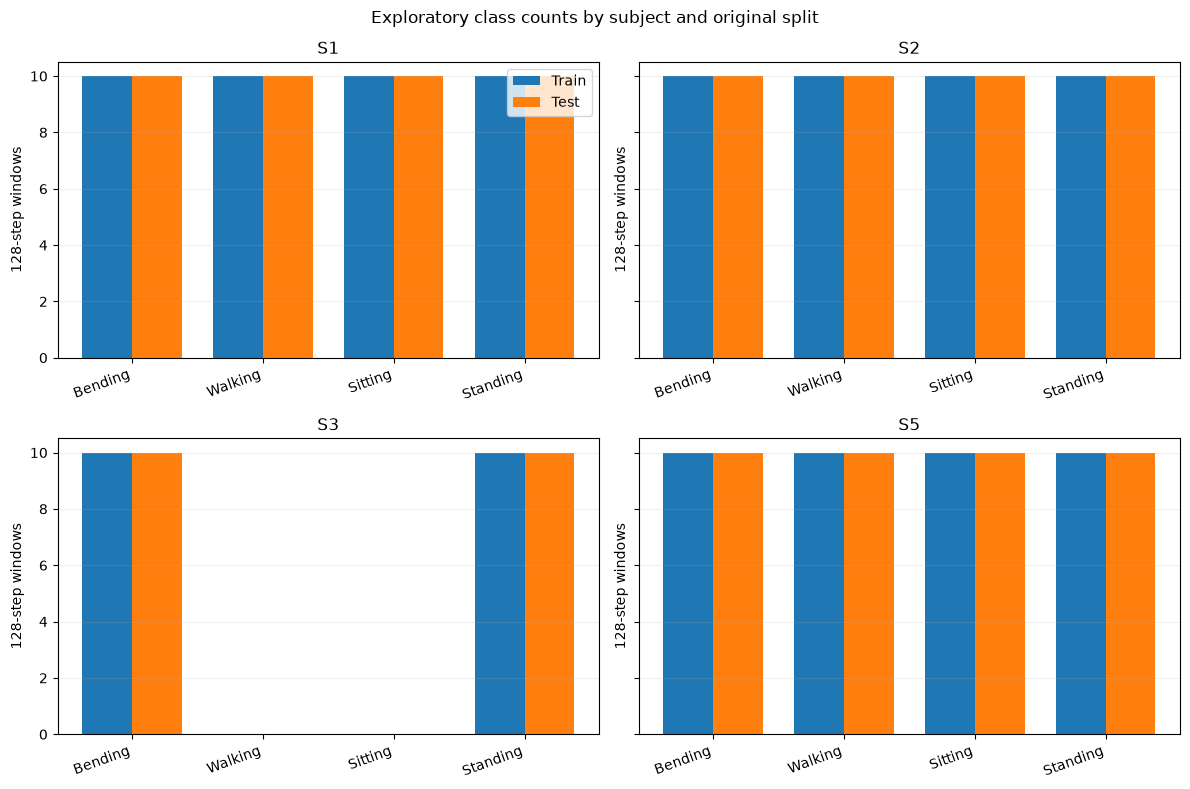

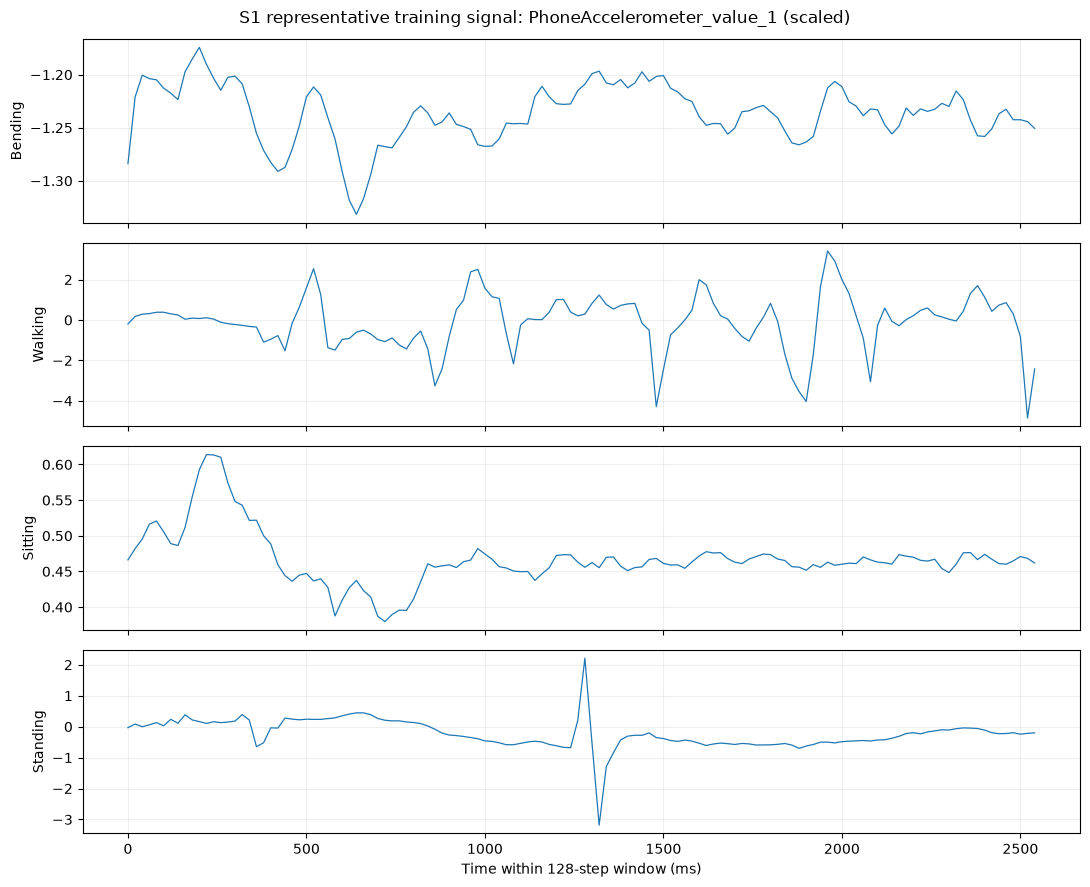

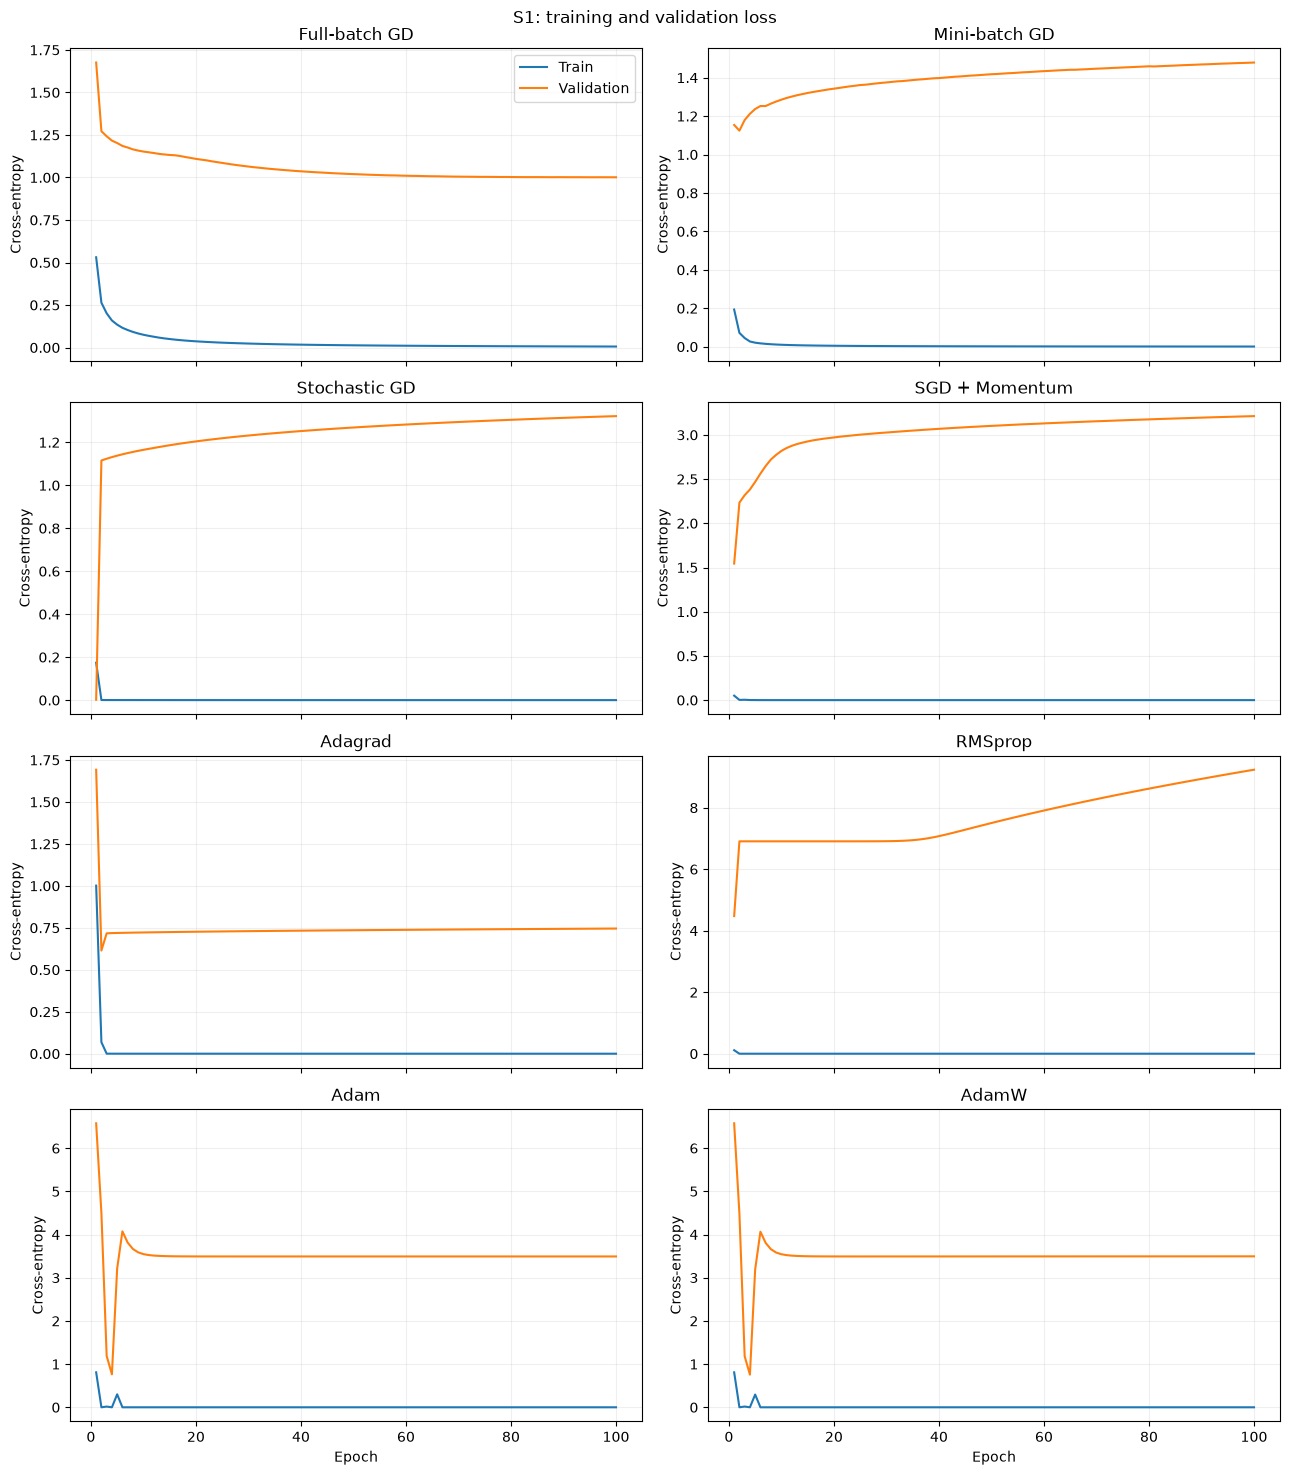

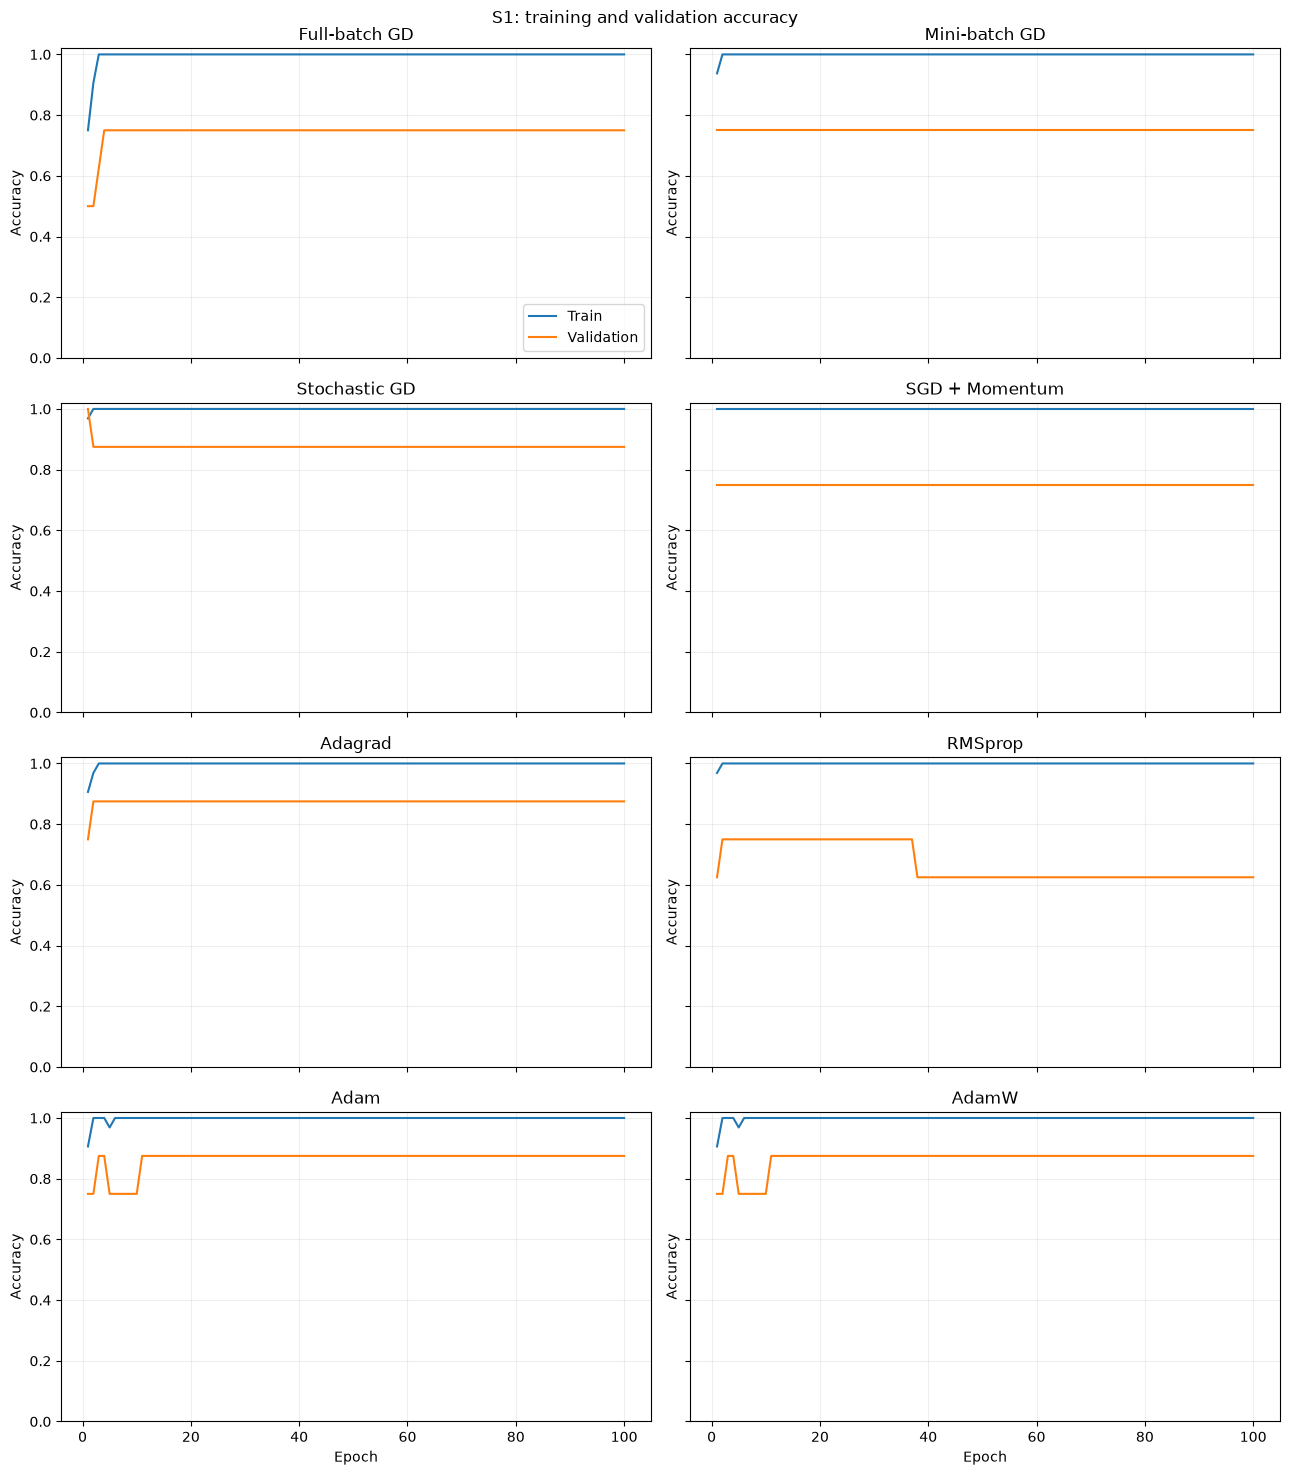

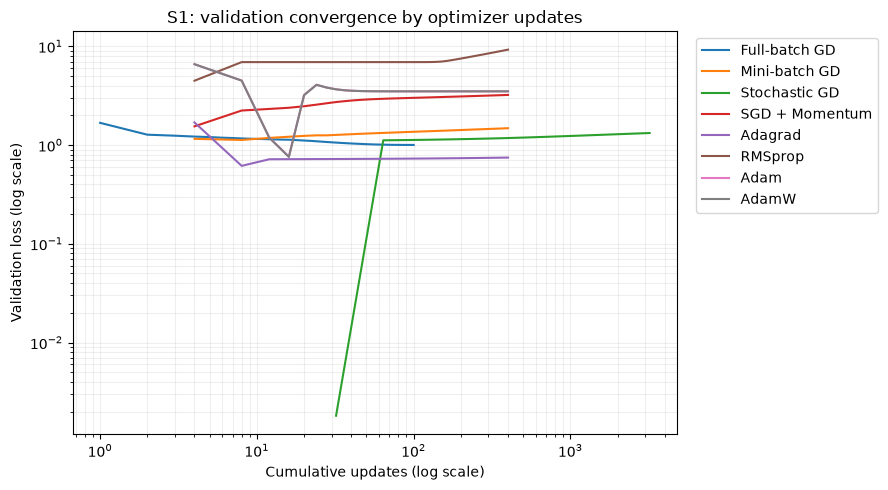

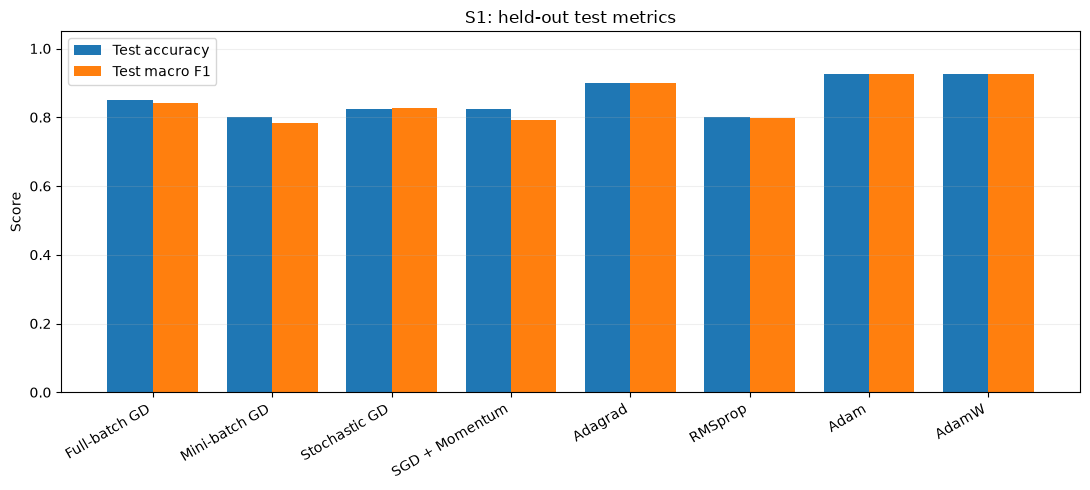

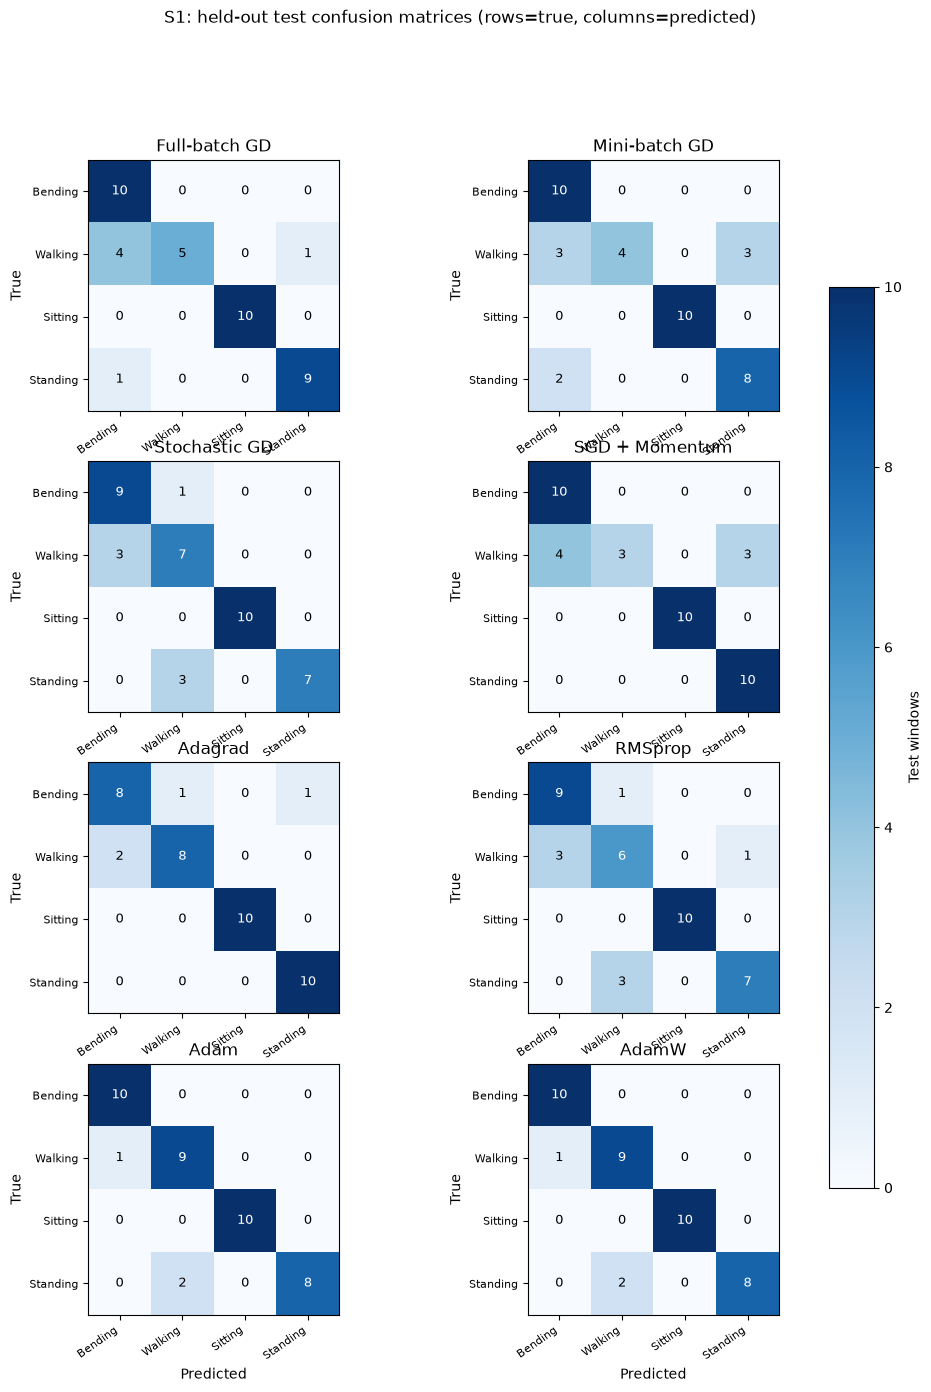

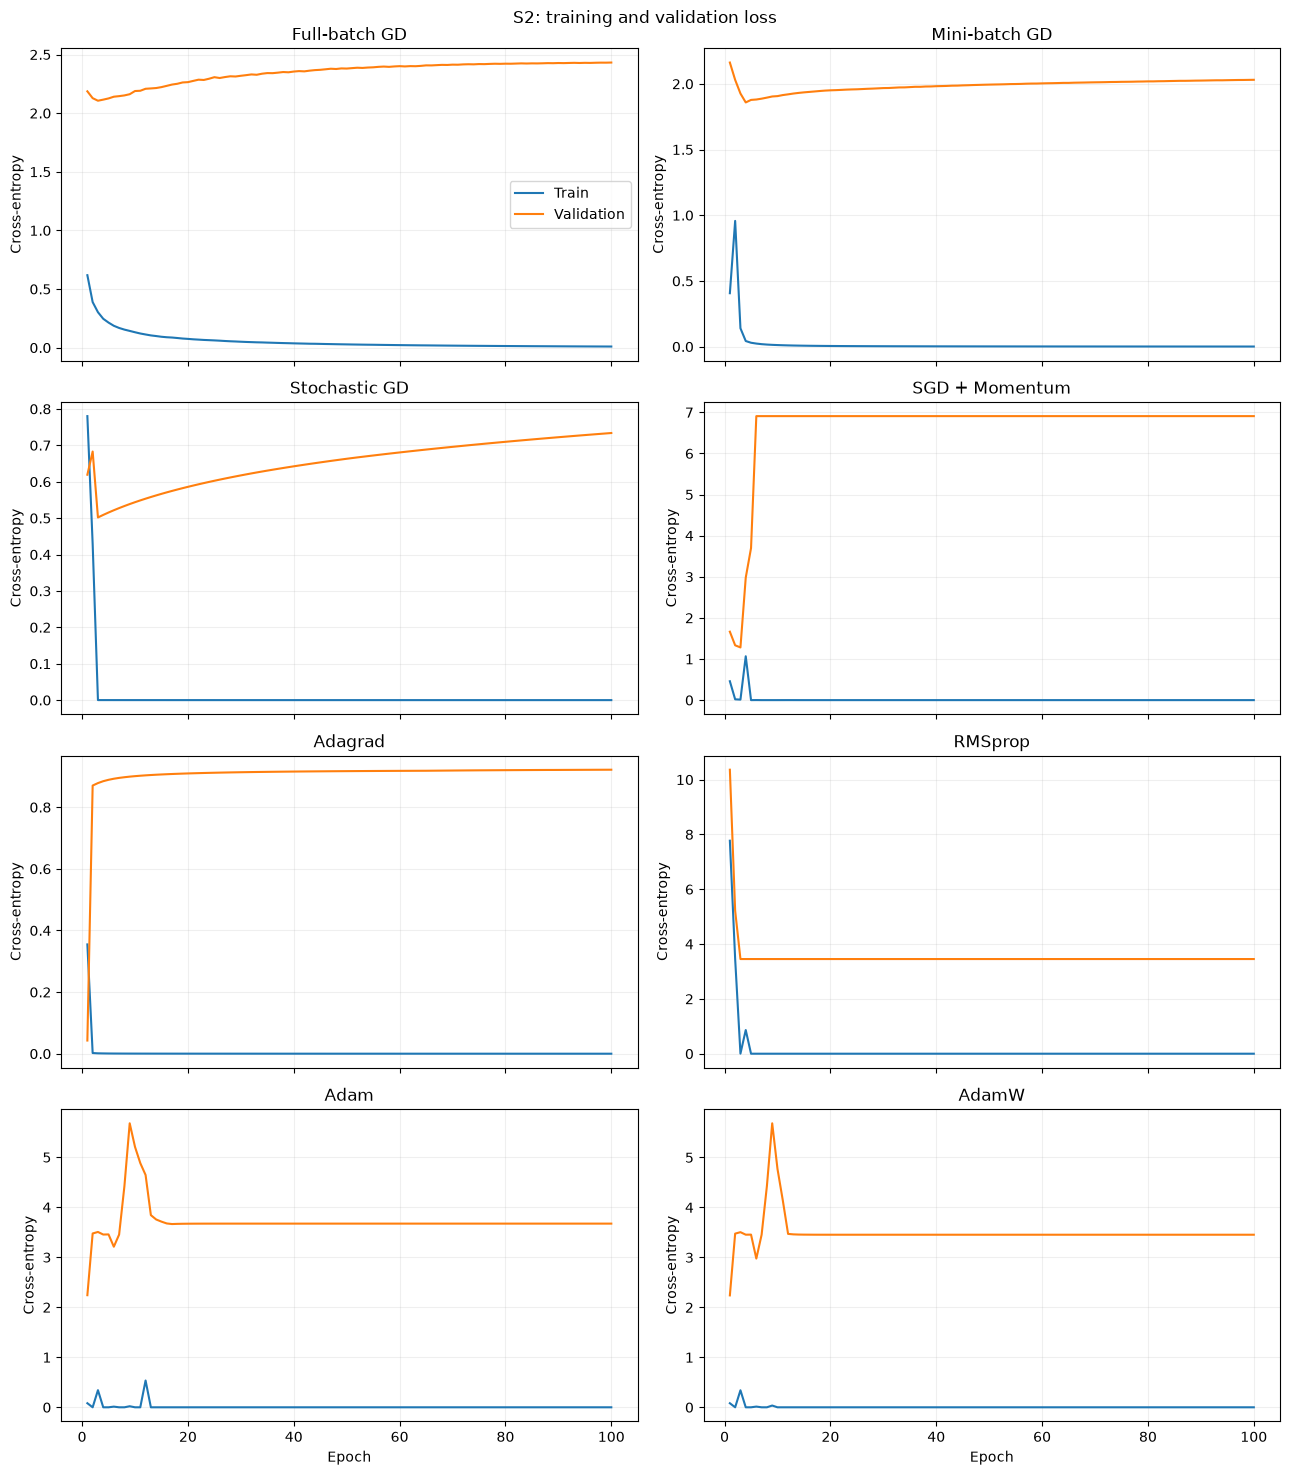

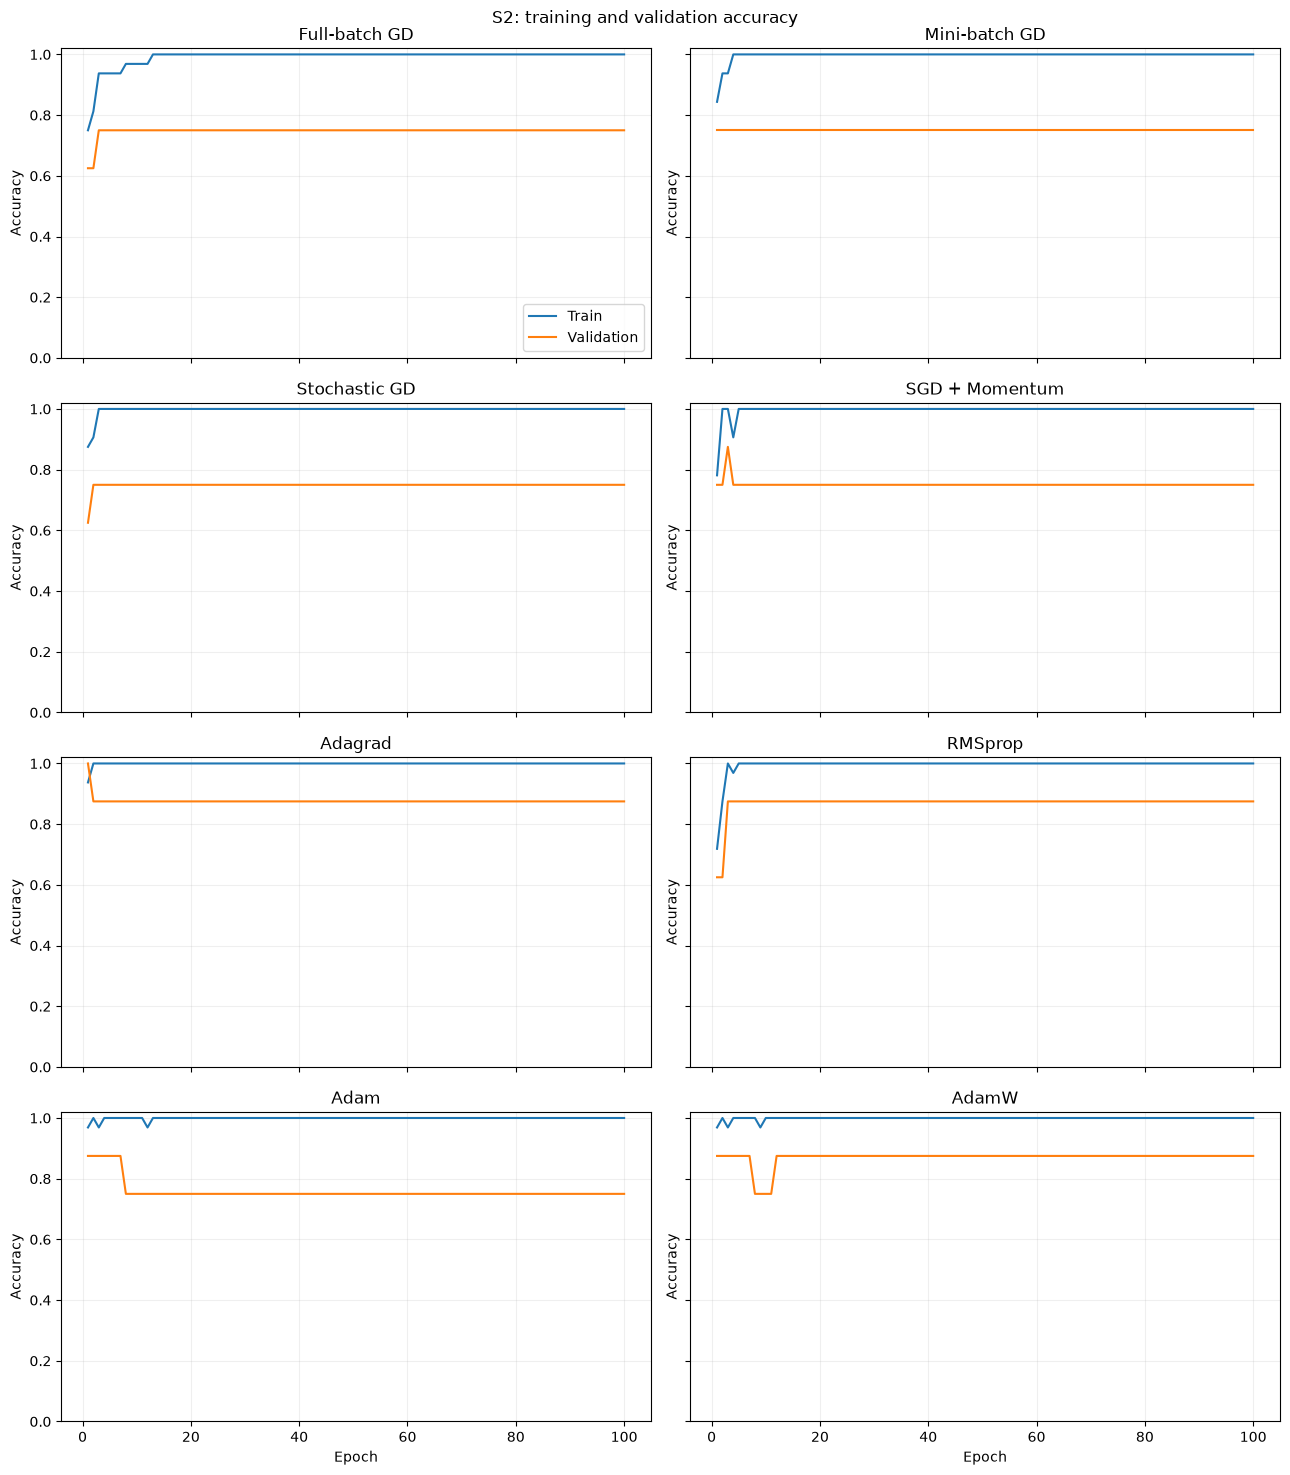

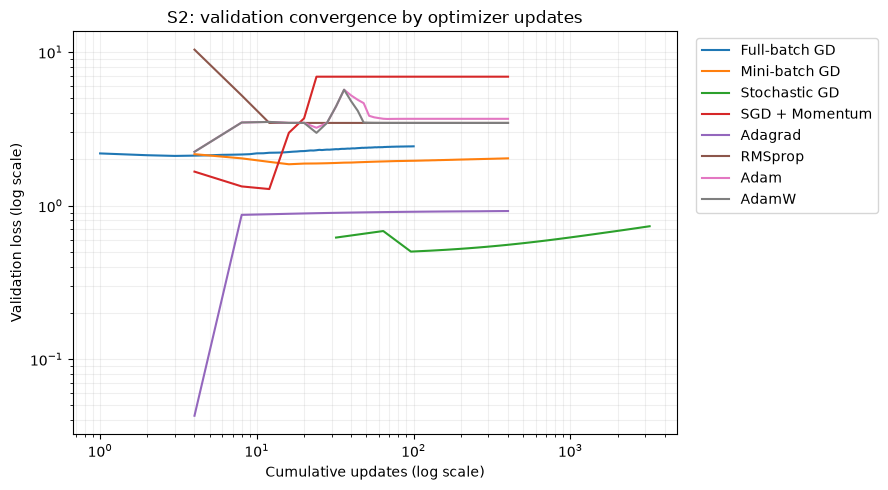

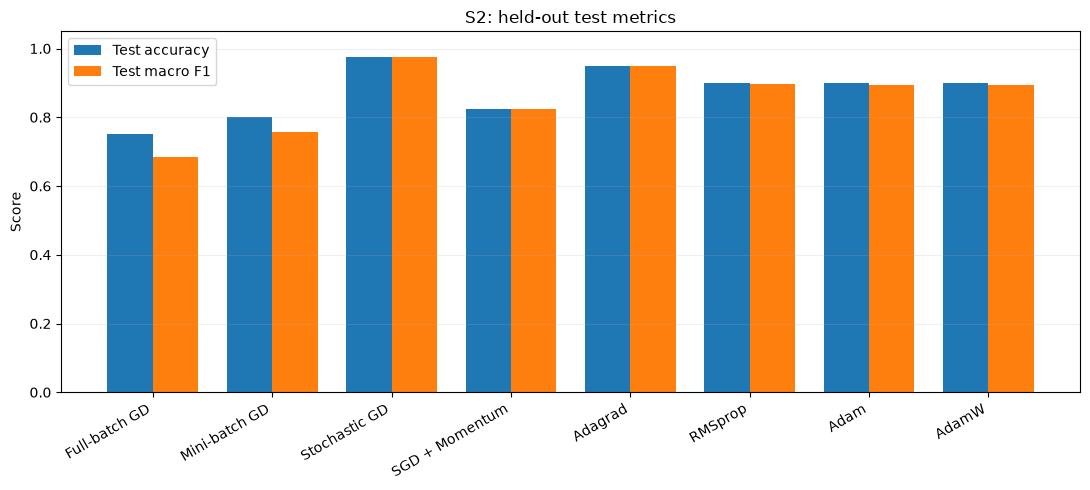

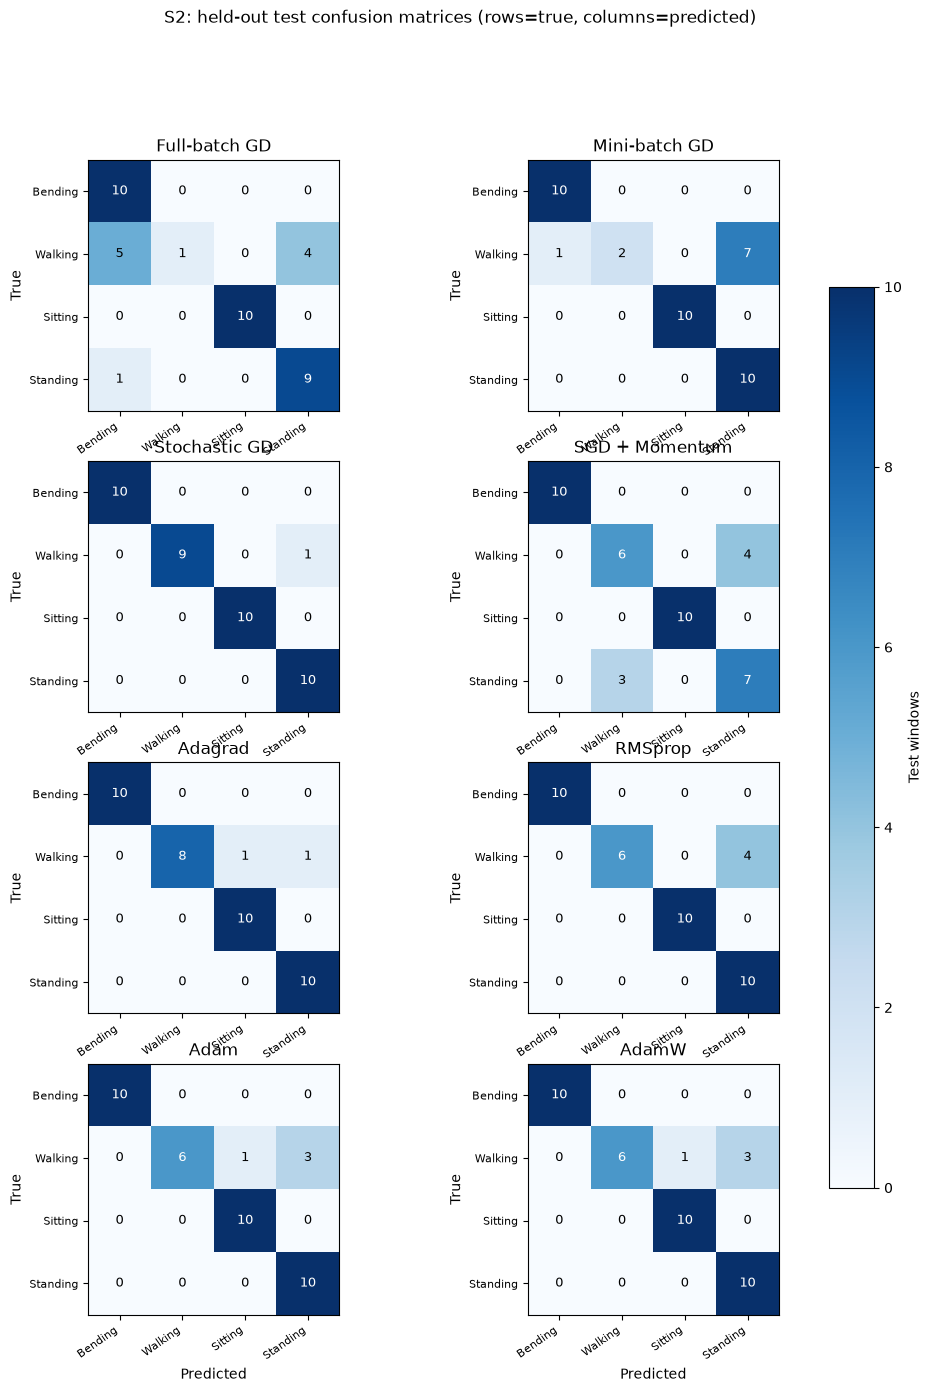

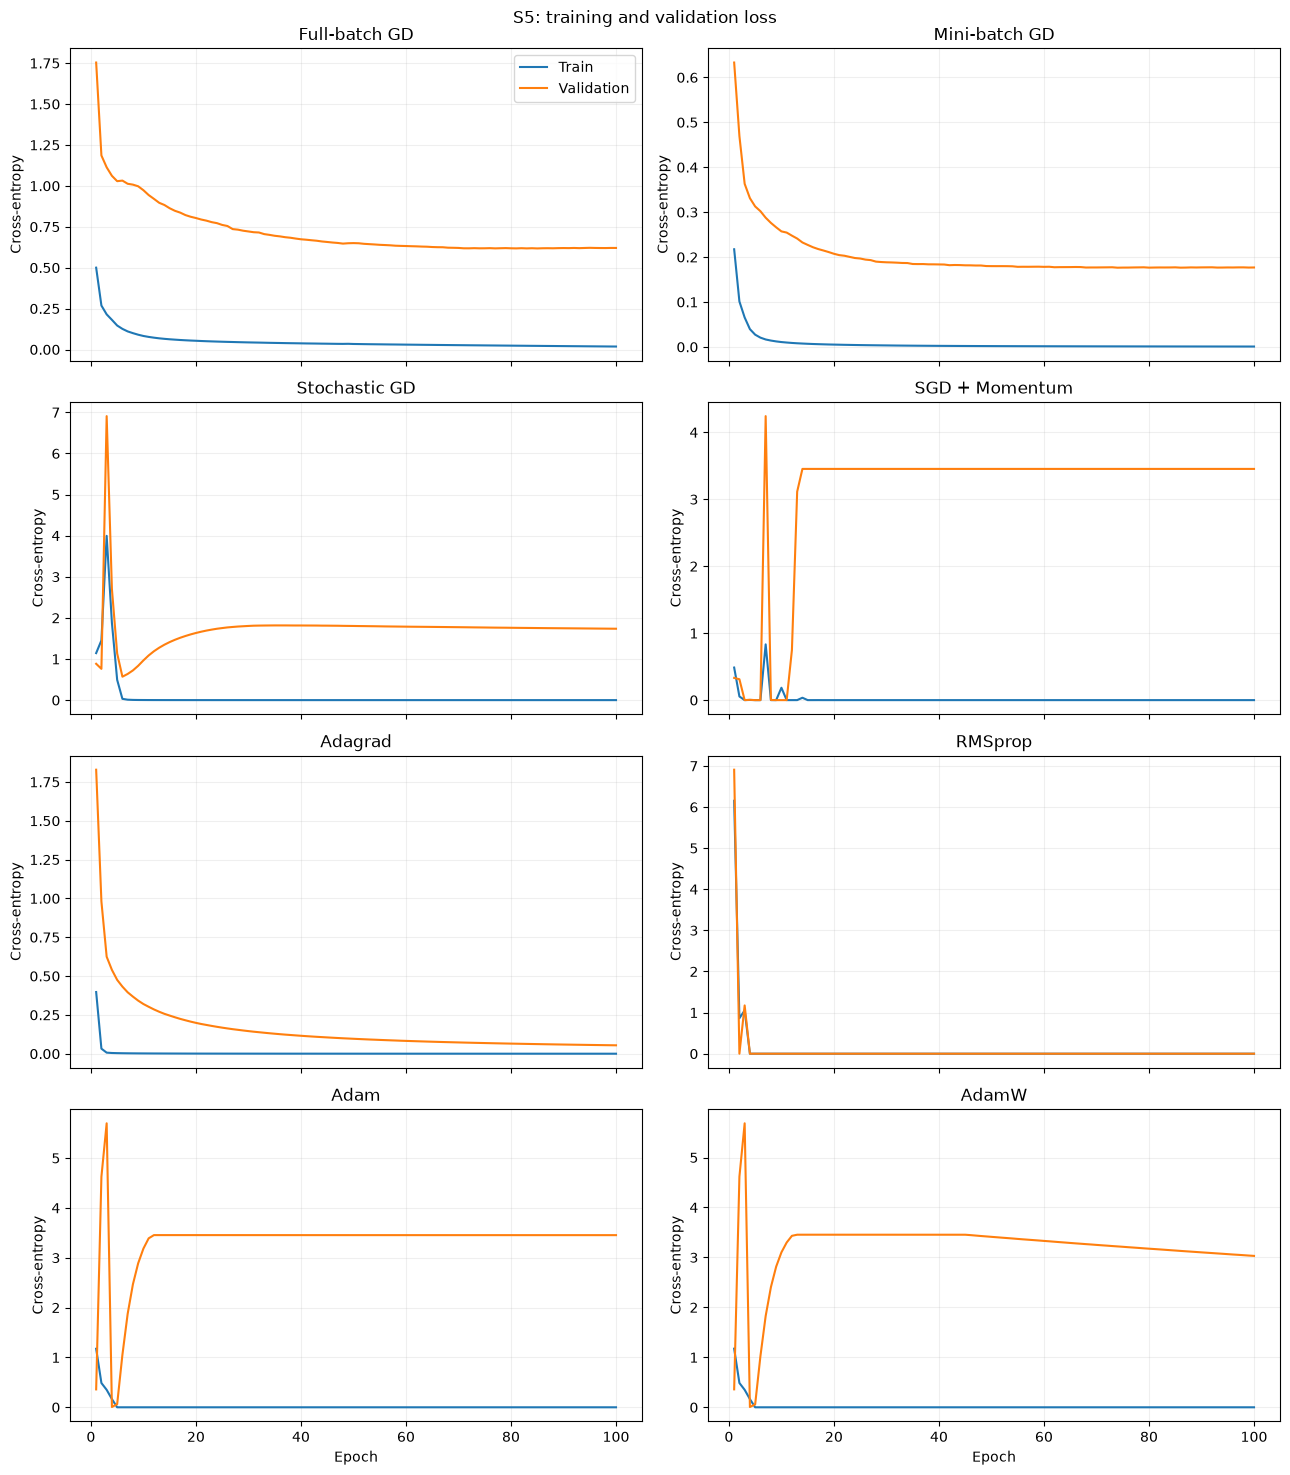

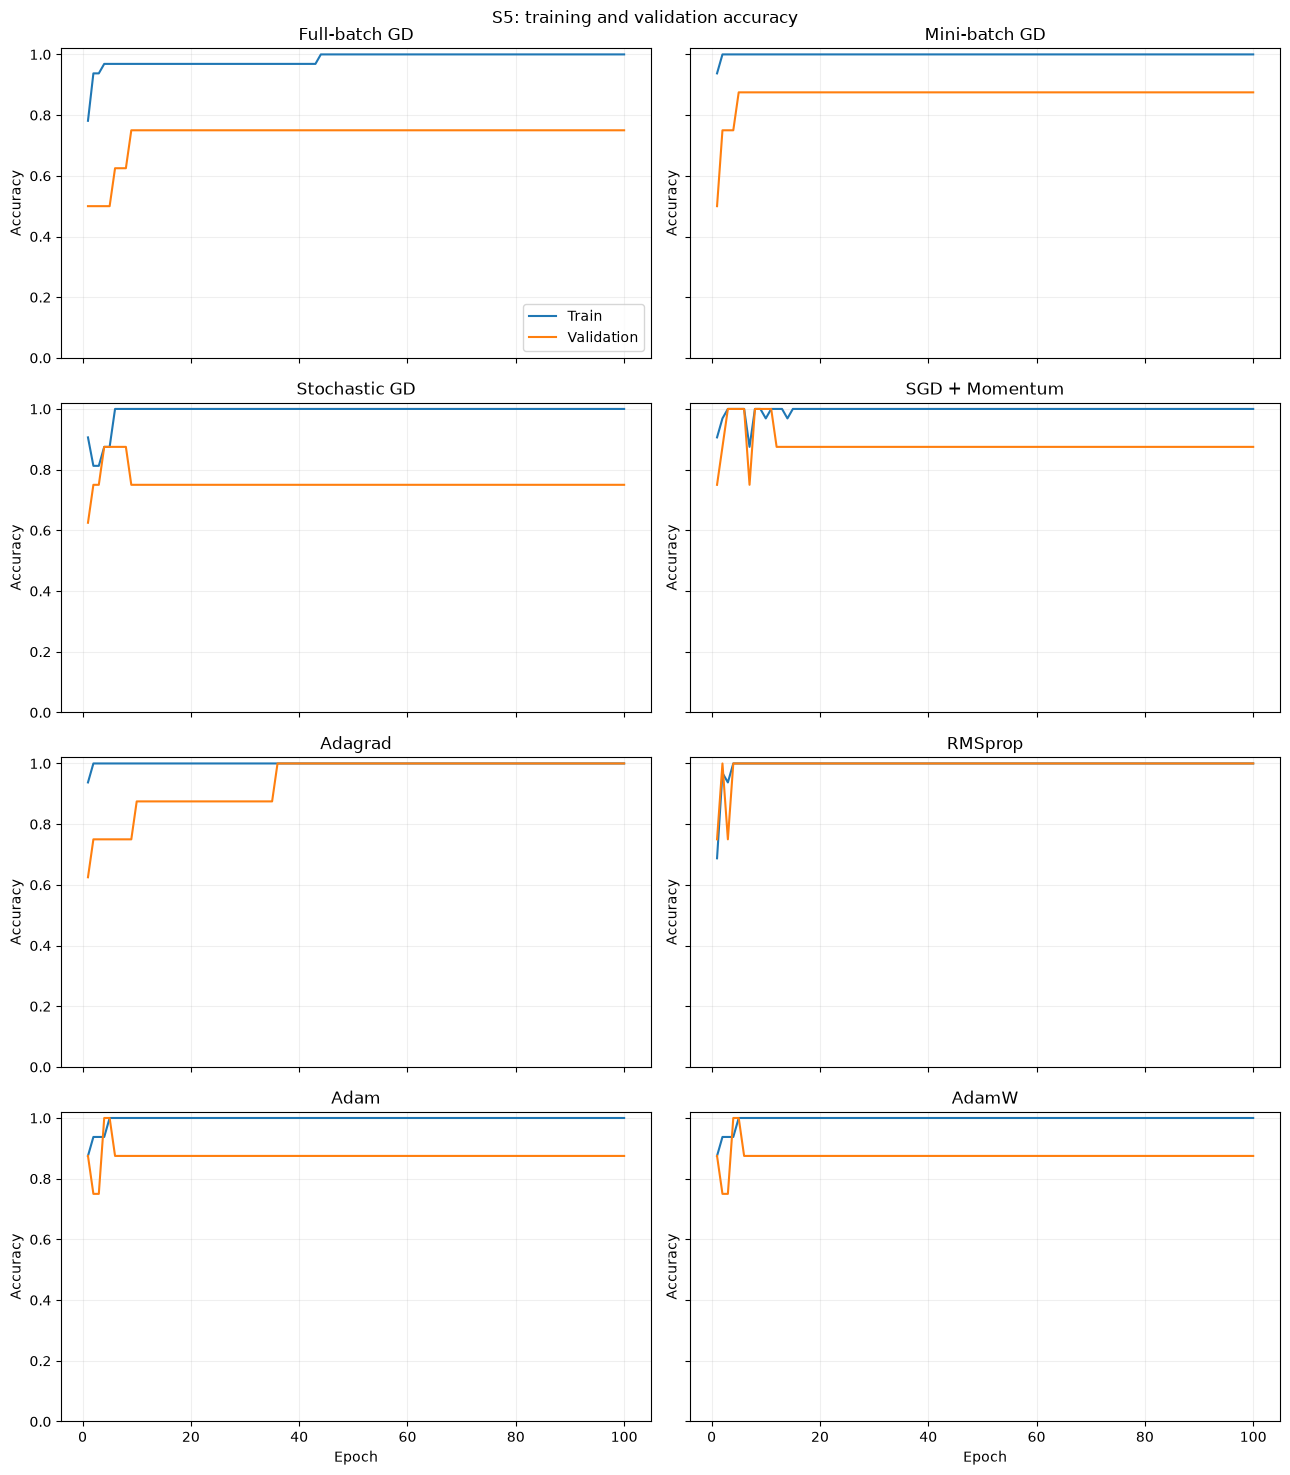

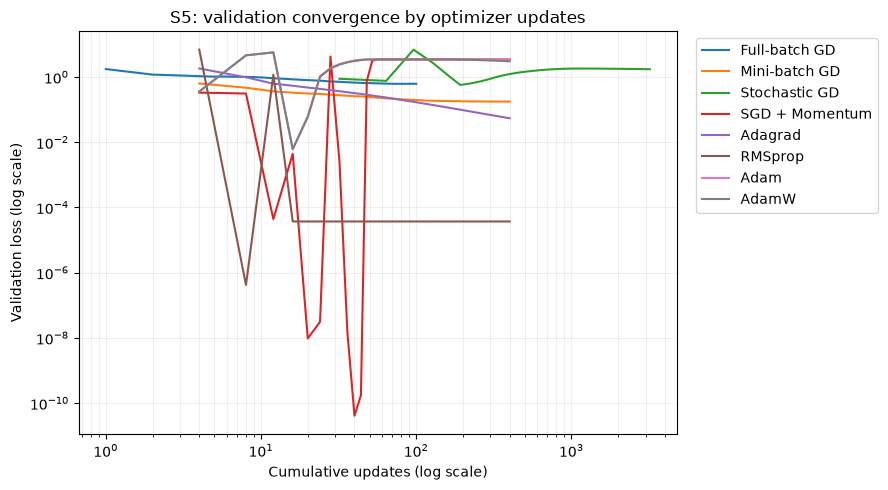

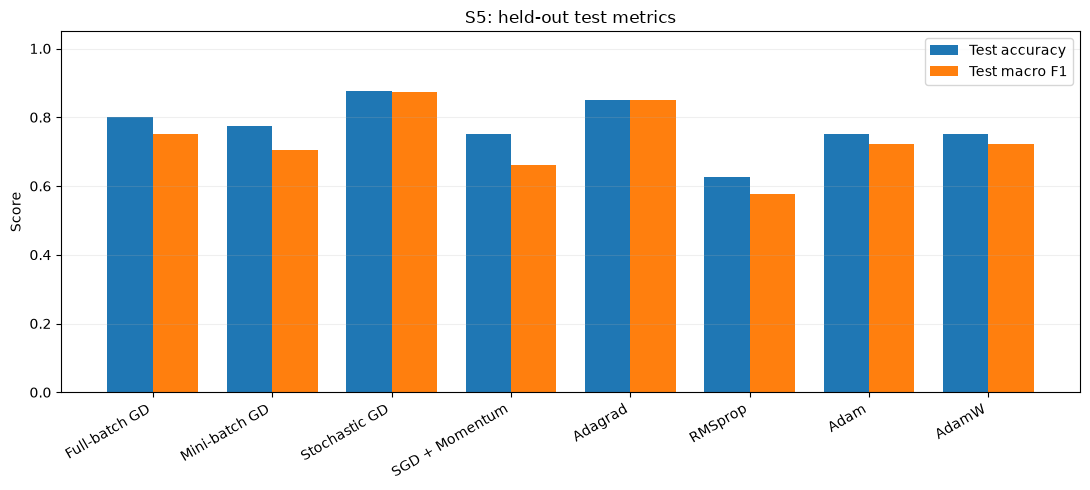

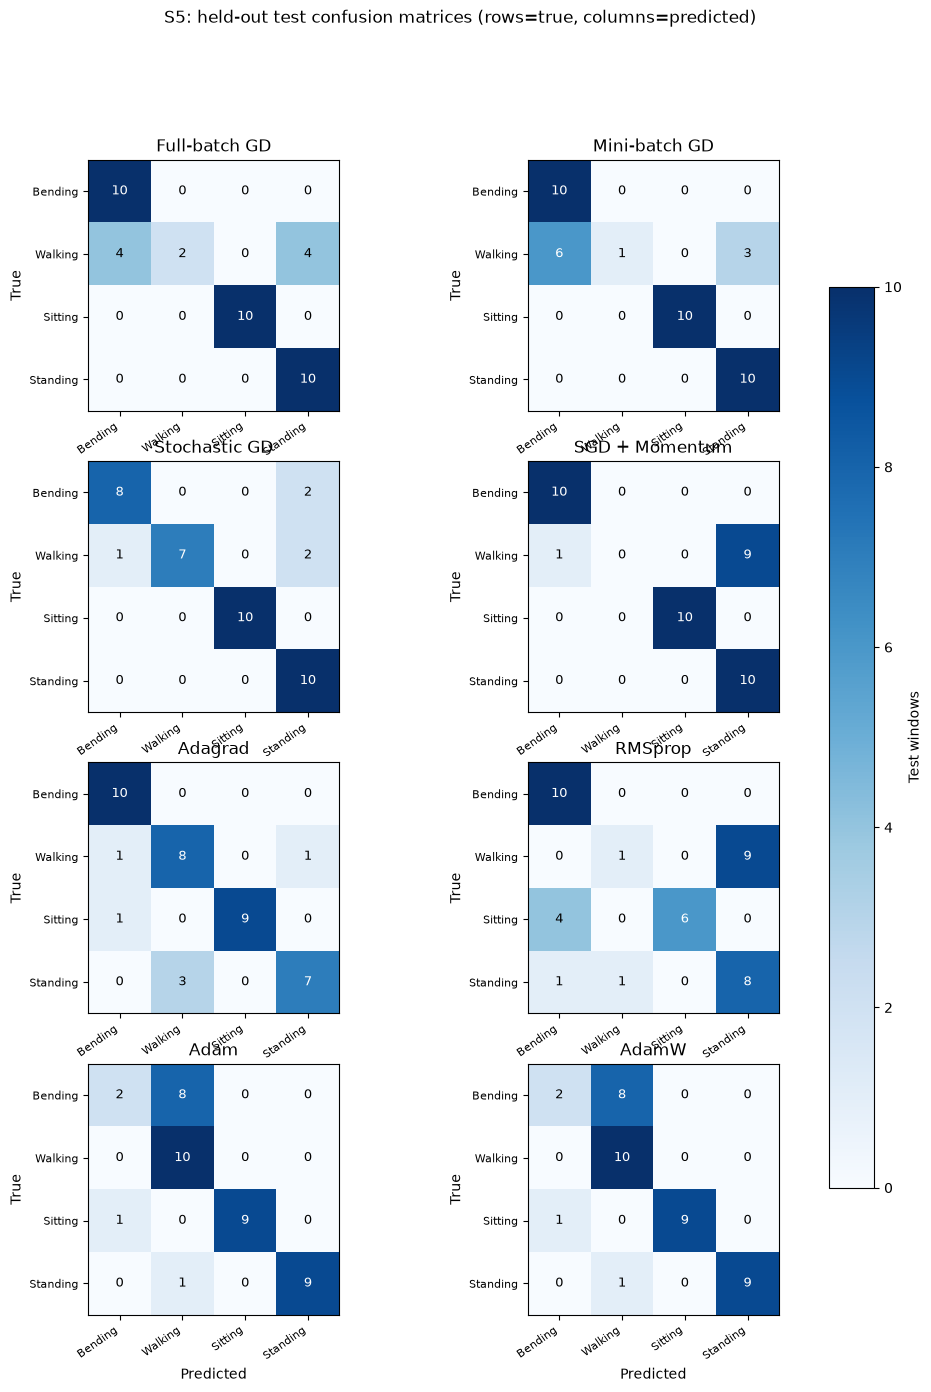

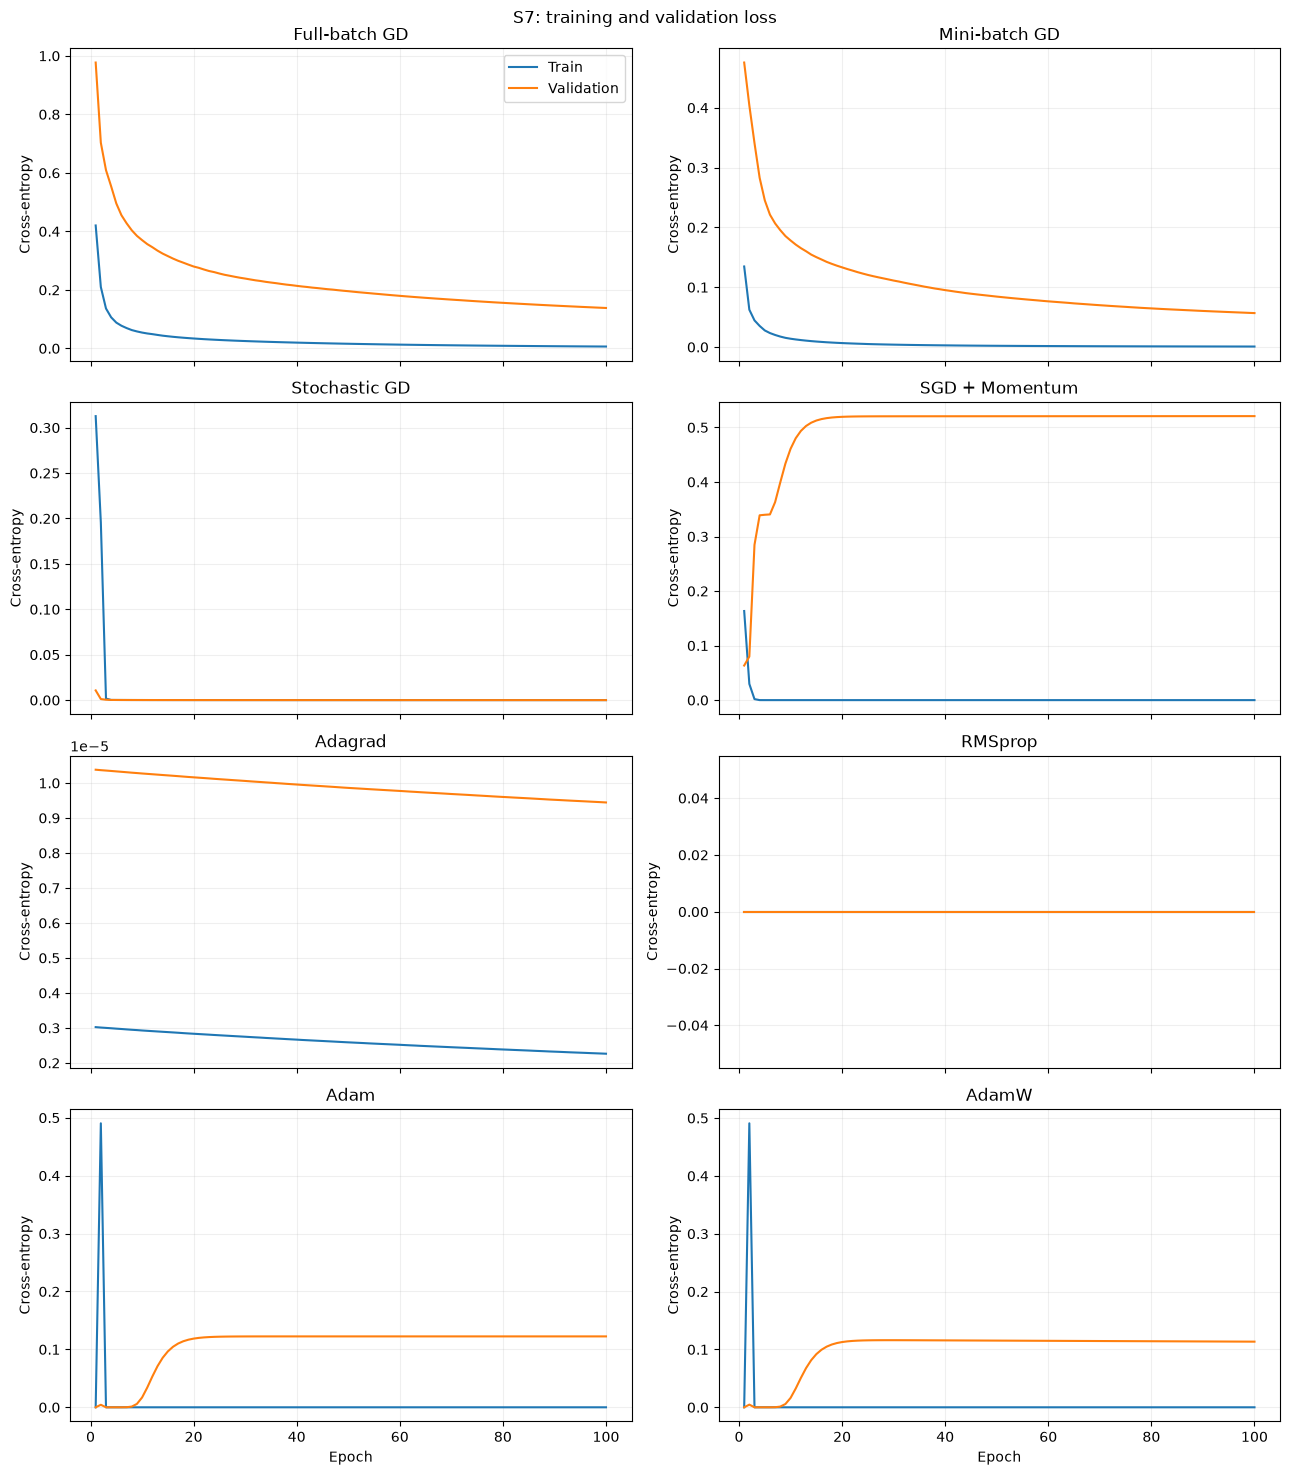

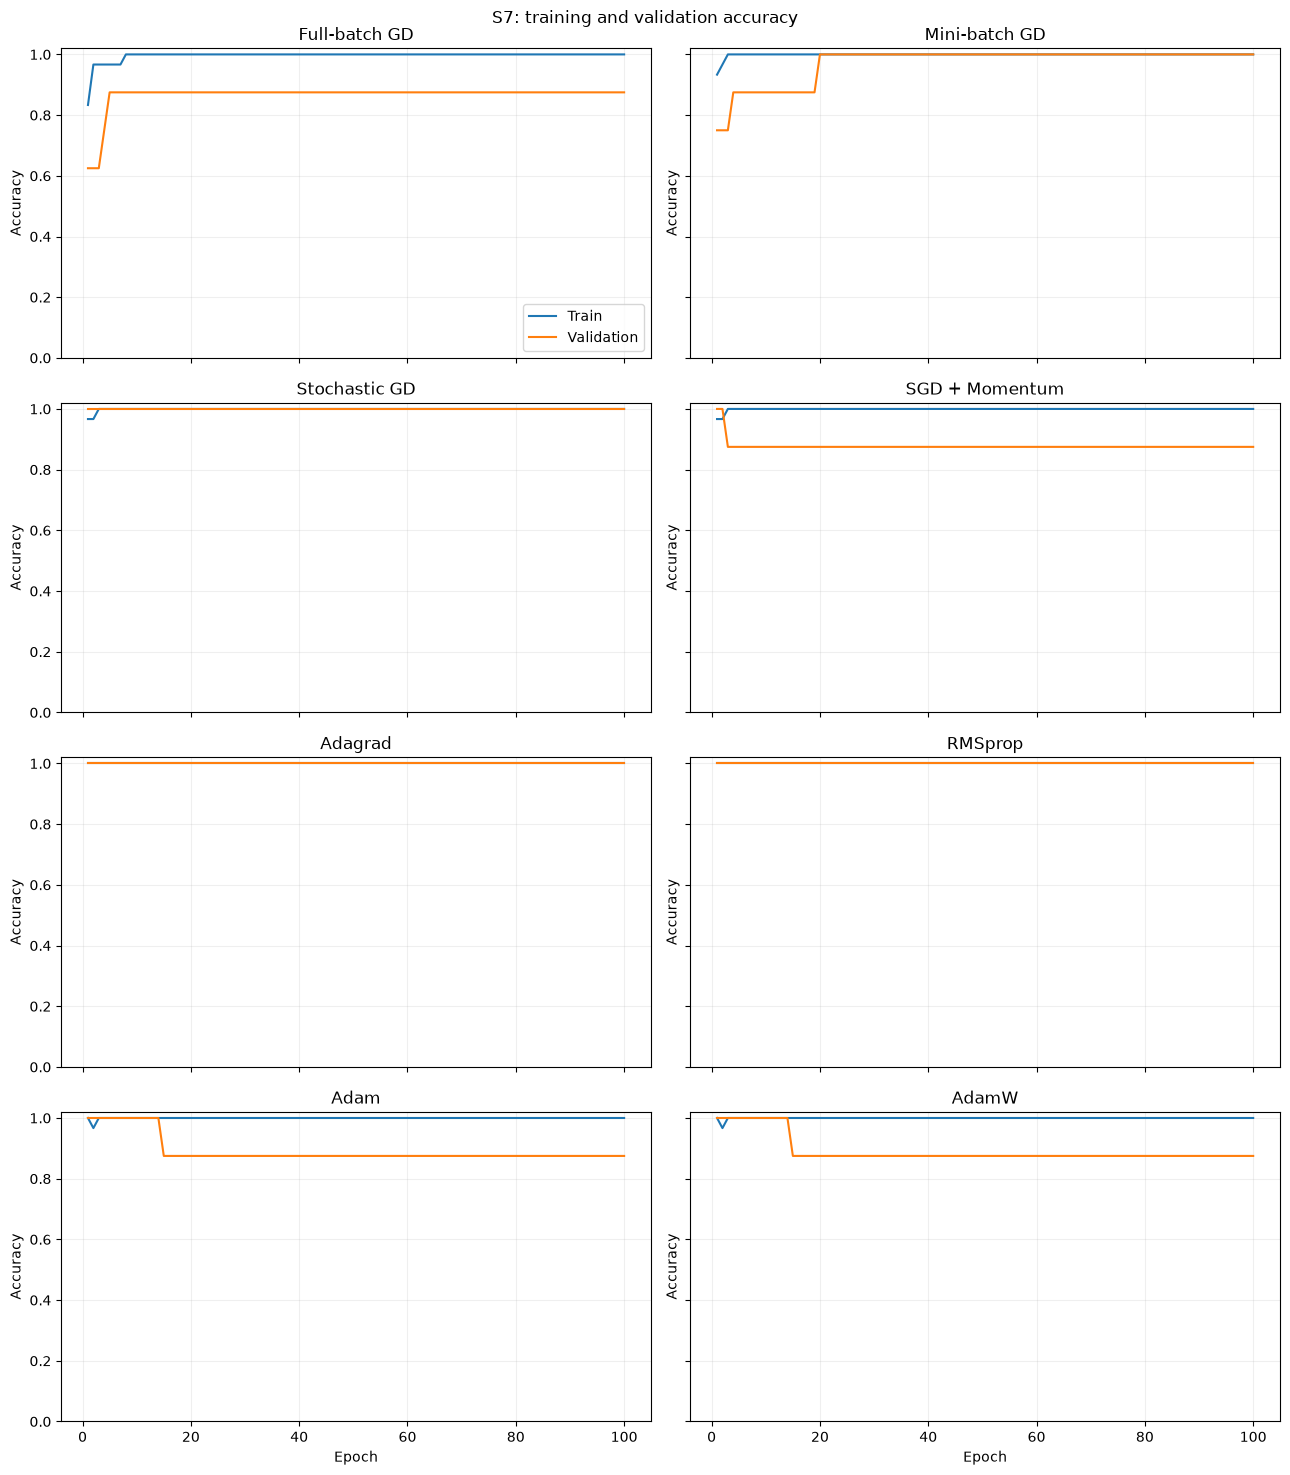

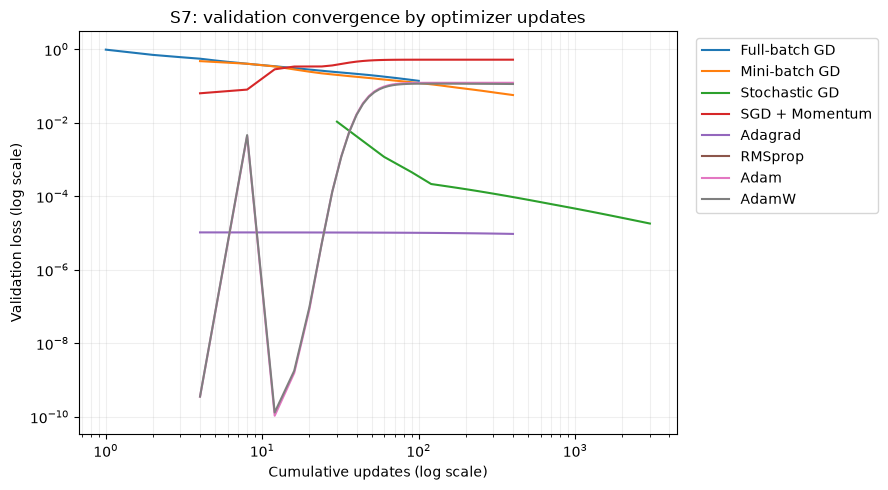

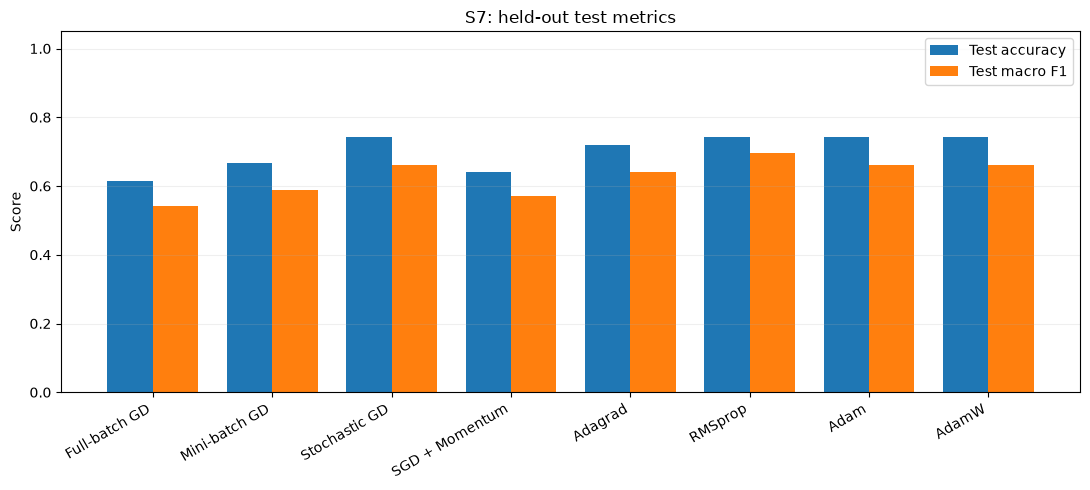

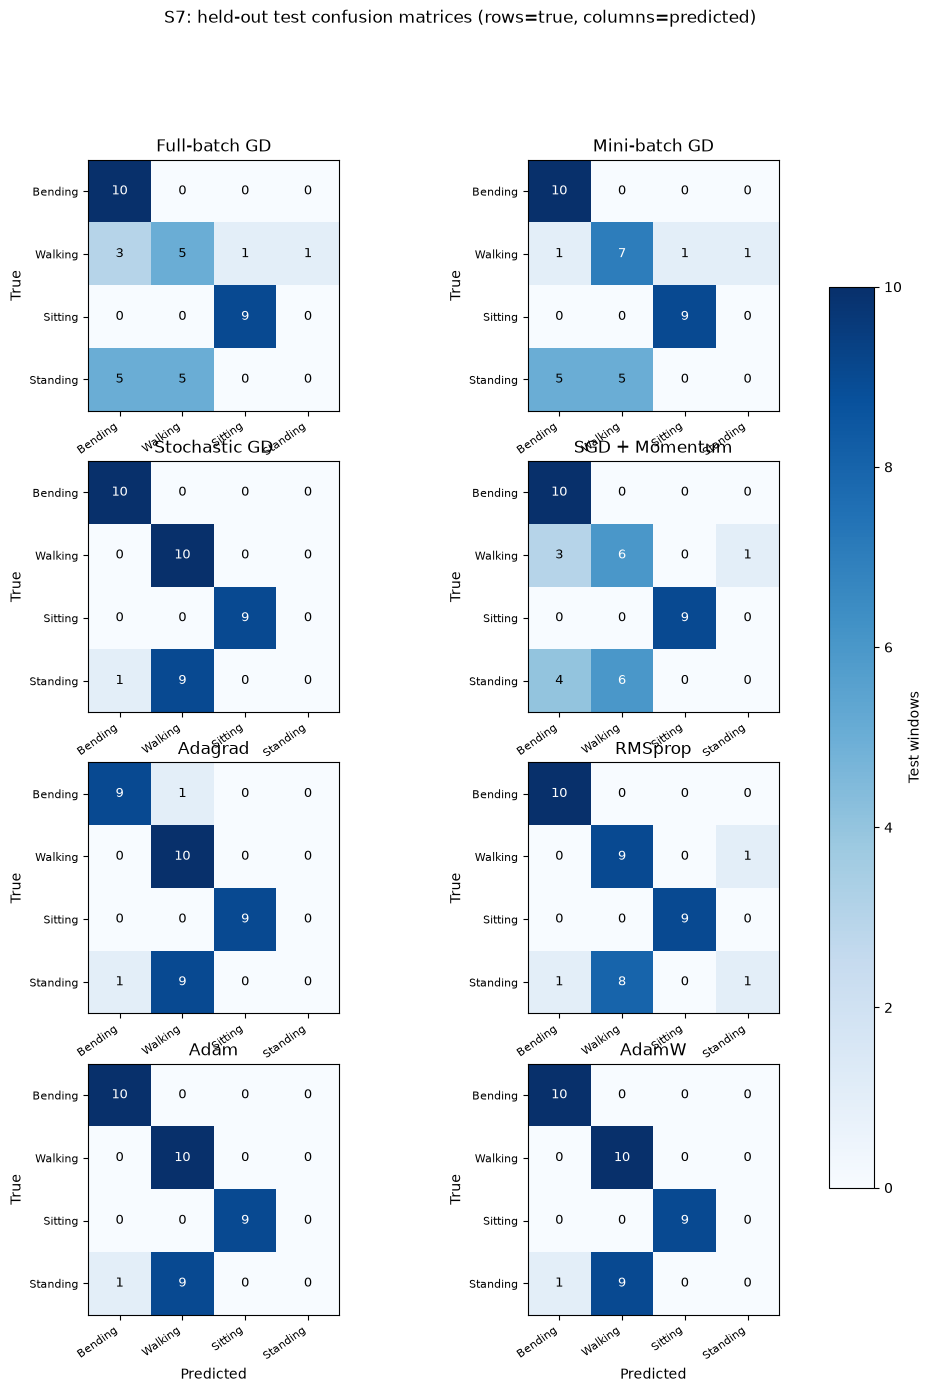

Saved EDA and subject-wise comparison figures under: D:\7th sem\ML\DATASETS\Annonmazed_CogActivity\DATA_PREP\all_subjects_experiments\run_20261003_105913\figures


In [6]:
from IPython.display import Image, display

FIGURE_ROOT = EXPERIMENT_DIR / 'figures'
FIGURE_ROOT.mkdir(parents=True, exist_ok=False)
optimizer_names = [item['name'] for item in OPTIMIZERS]

# Assignment EDA figure 1: original train/test window counts by class and subject.
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
for axis, (subject, dataset) in zip(axes.flat, SUBJECT_DATASETS.items()):
    train_counts = Counter(dataset['y_train'].tolist())
    test_counts = Counter(dataset['y_test'].tolist())
    x = np.arange(len(CLASS_IDS))
    width = 0.38
    axis.bar(x - width / 2, [train_counts[int(c)] for c in CLASS_IDS], width, label='Train')
    axis.bar(x + width / 2, [test_counts[int(c)] for c in CLASS_IDS], width, label='Test')
    axis.set_xticks(x, [CLASS_NAMES[int(c)] for c in CLASS_IDS], rotation=20, ha='right')
    axis.set_title(subject)
    axis.set_ylabel('128-step windows')
    axis.grid(axis='y', alpha=0.2)
axes[0, 0].legend()
fig.suptitle('Exploratory class counts by subject and original split')
fig.tight_layout()
fig.savefig(FIGURE_ROOT / 'class_counts_by_subject.png', dpi=170, bbox_inches='tight')
plt.show()

# Assignment EDA figure 2: one representative PhoneAccelerometer feature by class.
reference_subject = next((sid for sid in ('S1', 'S2', 'S5', 'S7') if sid in SUBJECT_DATASETS), None)
if reference_subject is not None:
    reference = SUBJECT_DATASETS[reference_subject]
    feature_index = next(
        (i for i, name in enumerate(reference['feature_names']) if 'PhoneAccelerometer' in name), 0
    )
    fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
    for axis, class_id in zip(axes, CLASS_IDS):
        sample_indices = np.flatnonzero(reference['y_train'] == class_id)
        if len(sample_indices):
            axis.plot(
                np.arange(128) * 20,
                reference['X_train'][sample_indices[0], :, feature_index],
                linewidth=0.9,
            )
            axis.set_ylabel(CLASS_NAMES[int(class_id)])
        else:
            axis.text(0.5, 0.5, 'No training sample', ha='center', va='center', transform=axis.transAxes)
        axis.grid(alpha=0.2)
    axes[-1].set_xlabel('Time within 128-step window (ms)')
    fig.suptitle(f'{reference_subject} representative training signal: {reference["feature_names"][feature_index]} (scaled)')
    fig.tight_layout()
    fig.savefig(FIGURE_ROOT / 'representative_sensor_by_class.png', dpi=170, bbox_inches='tight')
    plt.show()

# Per-subject optimizer curves and per-run 4 x 4 test confusion matrices.
for subject in MODEL_DATA:
    subject_figure_dir = FIGURE_ROOT / subject
    subject_figure_dir.mkdir(parents=True, exist_ok=False)

    fig, axes = plt.subplots(4, 2, figsize=(13, 15), sharex=True)
    for axis, optimizer_name in zip(axes.flat, optimizer_names):
        history = experiment_histories[(subject, optimizer_name)]
        axis.plot(history['epoch'], history['train_loss'], label='Train')
        axis.plot(history['epoch'], history['validation_loss'], label='Validation')
        axis.set_title(optimizer_name)
        axis.set_ylabel('Cross-entropy')
        axis.grid(alpha=0.2)
    axes[0, 0].legend()
    axes[-1, 0].set_xlabel('Epoch')
    axes[-1, 1].set_xlabel('Epoch')
    fig.suptitle(f'{subject}: training and validation loss')
    fig.tight_layout()
    fig.savefig(subject_figure_dir / 'loss_by_epoch.png', dpi=160, bbox_inches='tight')
    plt.show()

    fig, axes = plt.subplots(4, 2, figsize=(13, 15), sharex=True, sharey=True)
    for axis, optimizer_name in zip(axes.flat, optimizer_names):
        history = experiment_histories[(subject, optimizer_name)]
        axis.plot(history['epoch'], history['train_accuracy'], label='Train')
        axis.plot(history['epoch'], history['validation_accuracy'], label='Validation')
        axis.set_title(optimizer_name)
        axis.set_ylabel('Accuracy')
        axis.set_ylim(0, 1.02)
        axis.grid(alpha=0.2)
    axes[0, 0].legend(loc='lower right')
    axes[-1, 0].set_xlabel('Epoch')
    axes[-1, 1].set_xlabel('Epoch')
    fig.suptitle(f'{subject}: training and validation accuracy')
    fig.tight_layout()
    fig.savefig(subject_figure_dir / 'accuracy_by_epoch.png', dpi=160, bbox_inches='tight')
    plt.show()

    fig, axis = plt.subplots(figsize=(9, 5))
    for optimizer_name in optimizer_names:
        history = experiment_histories[(subject, optimizer_name)]
        axis.plot(history['cumulative_updates'], history['validation_loss'], label=optimizer_name)
    axis.set_xscale('log')
    axis.set_yscale('log')
    axis.set_xlabel('Cumulative updates (log scale)')
    axis.set_ylabel('Validation loss (log scale)')
    axis.set_title(f'{subject}: validation convergence by optimizer updates')
    axis.grid(alpha=0.2, which='both')
    axis.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    fig.tight_layout()
    fig.savefig(subject_figure_dir / 'validation_loss_by_updates.png', dpi=160, bbox_inches='tight')
    plt.show()

    subject_results = experiment_results[experiment_results['subject'] == subject].set_index('optimizer').loc[optimizer_names].reset_index()
    positions = np.arange(len(optimizer_names))
    bar_width = 0.38
    fig, axis = plt.subplots(figsize=(11, 5))
    axis.bar(positions - bar_width / 2, subject_results['test_accuracy'], bar_width, label='Test accuracy')
    axis.bar(positions + bar_width / 2, subject_results['test_macro_f1'], bar_width, label='Test macro F1')
    axis.set_xticks(positions, optimizer_names, rotation=30, ha='right')
    axis.set_ylim(0, 1.05)
    axis.set_ylabel('Score')
    axis.set_title(f'{subject}: held-out test metrics')
    axis.legend()
    axis.grid(axis='y', alpha=0.2)
    fig.tight_layout()
    fig.savefig(subject_figure_dir / 'test_metrics_by_optimizer.png', dpi=160, bbox_inches='tight')
    plt.show()

    fig, axes = plt.subplots(4, 2, figsize=(13, 15))
    for axis, optimizer_name in zip(axes.flat, optimizer_names):
        matrix = experiment_confusions[(subject, optimizer_name)]
        image = axis.imshow(matrix, cmap='Blues', vmin=0, vmax=max(1, matrix.max()))
        axis.set_title(optimizer_name)
        axis.set_xticks(range(4), [CLASS_NAMES[int(c)] for c in CLASS_IDS], rotation=35, ha='right', fontsize=8)
        axis.set_yticks(range(4), [CLASS_NAMES[int(c)] for c in CLASS_IDS], fontsize=8)
        axis.set_xlabel('Predicted')
        axis.set_ylabel('True')
        for row in range(4):
            for column in range(4):
                axis.text(column, row, str(matrix[row, column]), ha='center', va='center', fontsize=9,
                          color='white' if matrix[row, column] > matrix.max() / 2 else 'black')
    fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.78, label='Test windows')
    fig.suptitle(f'{subject}: held-out test confusion matrices (rows=true, columns=predicted)')
    fig.savefig(subject_figure_dir / 'confusion_matrices.png', dpi=170, bbox_inches='tight')
    plt.show()

print('Saved EDA and subject-wise comparison figures under:', FIGURE_ROOT.resolve())

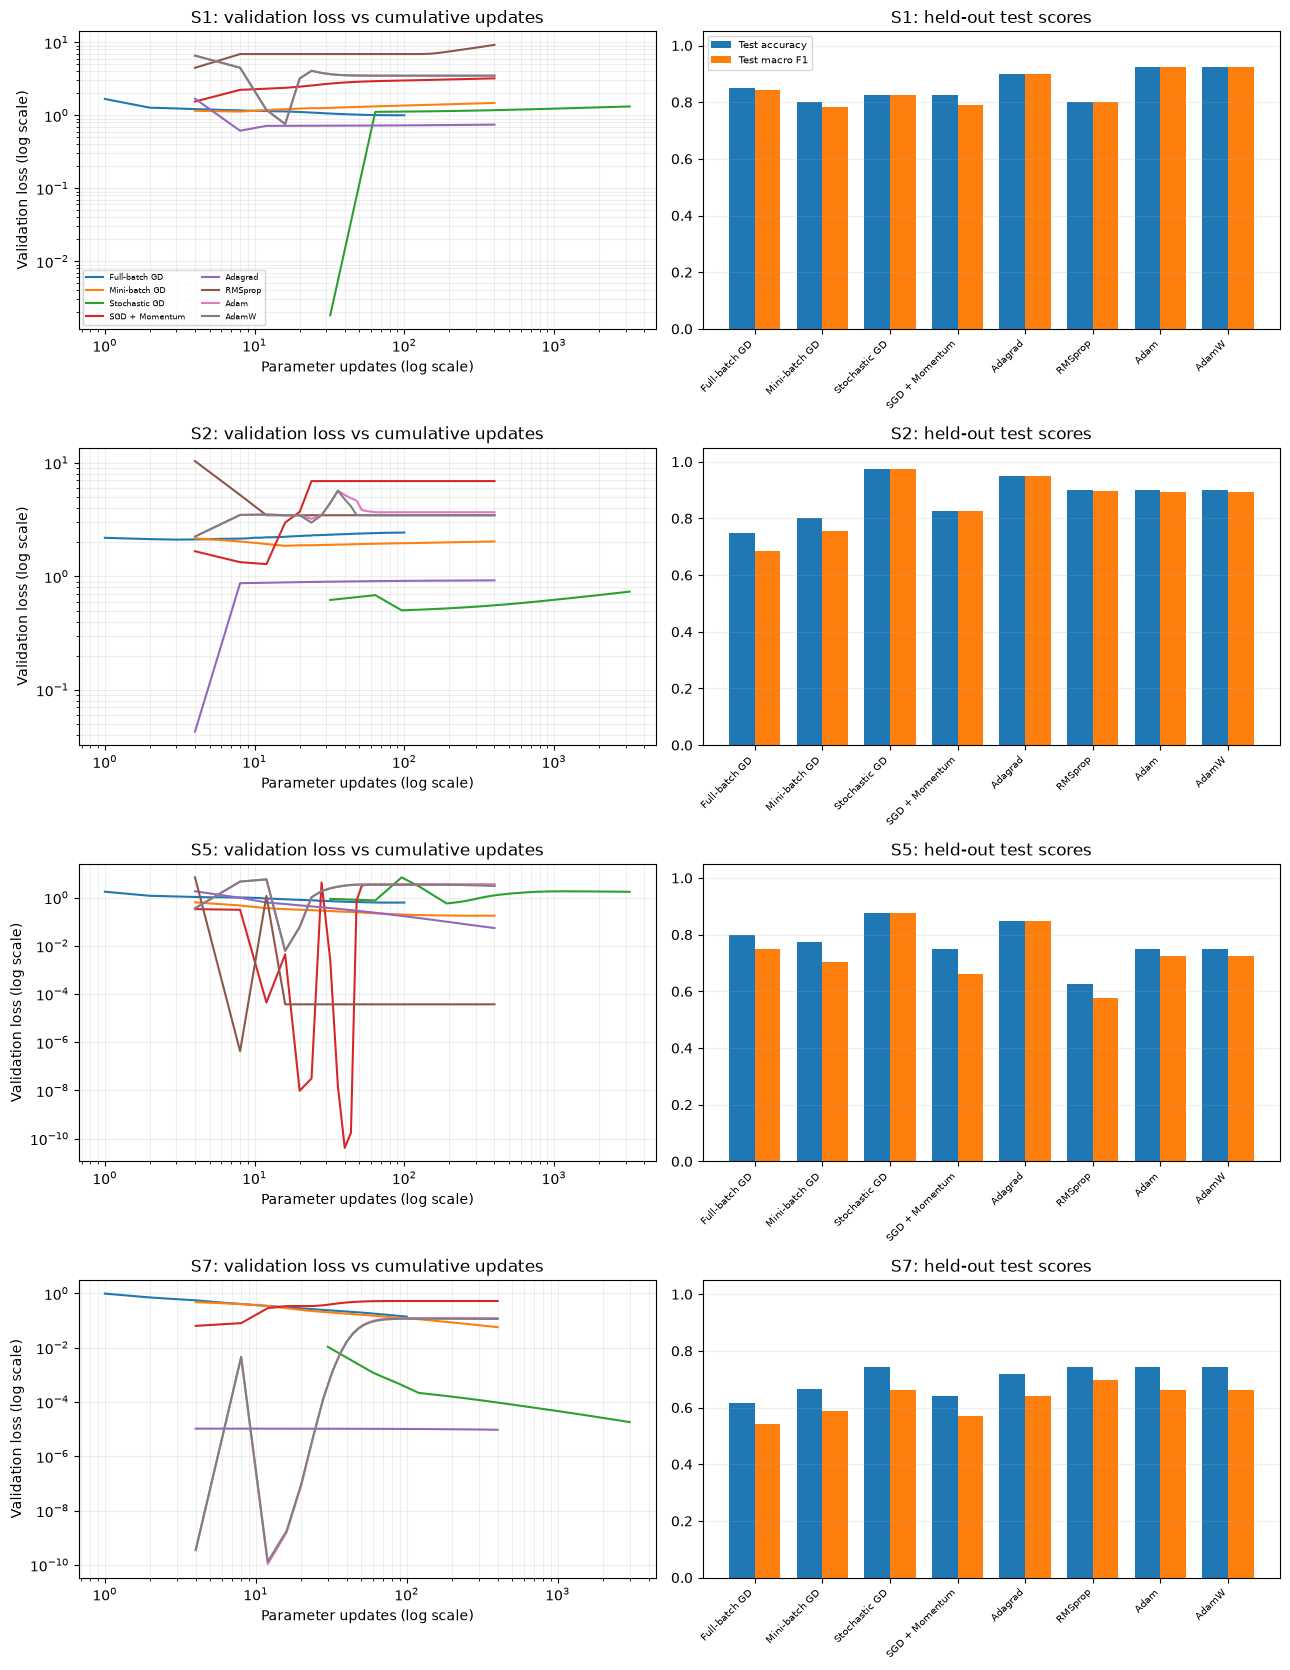

In [7]:
# Correctly align each subject's convergence curve and test-score chart into one row.
compare_fig, compare_axes = plt.subplots(len(MODEL_DATA), 2, figsize=(13, 4.2 * len(MODEL_DATA)))
if len(MODEL_DATA) == 1:
    compare_axes = np.asarray([compare_axes])
for row_index, (subject, subject_data) in enumerate(MODEL_DATA.items()):
    convergence_axis, score_axis = compare_axes[row_index]
    for optimizer_name in optimizer_names:
        history = experiment_histories[(subject, optimizer_name)]
        convergence_axis.plot(history['cumulative_updates'], history['validation_loss'], label=optimizer_name)
    convergence_axis.set_xscale('log')
    convergence_axis.set_yscale('log')
    convergence_axis.set_title(f'{subject}: validation loss vs cumulative updates')
    convergence_axis.set_xlabel('Parameter updates (log scale)')
    convergence_axis.set_ylabel('Validation loss (log scale)')
    convergence_axis.grid(alpha=0.2, which='both')

    subject_results = experiment_results[experiment_results['subject'] == subject].set_index('optimizer').loc[optimizer_names]
    positions = np.arange(len(optimizer_names))
    score_axis.bar(positions - 0.19, subject_results['test_accuracy'], 0.38, label='Test accuracy')
    score_axis.bar(positions + 0.19, subject_results['test_macro_f1'], 0.38, label='Test macro F1')
    score_axis.set_title(f'{subject}: held-out test scores')
    score_axis.set_xticks(positions, optimizer_names, rotation=45, ha='right', fontsize=7)
    score_axis.set_ylim(0, 1.05)
    score_axis.grid(axis='y', alpha=0.2)
    if row_index == 0:
        convergence_axis.legend(fontsize=6, ncol=2)
        score_axis.legend(fontsize=7)
compare_fig.tight_layout()
compare_path = FIGURE_ROOT / 'report_convergence_and_test_metrics.png'
compare_fig.savefig(compare_path, dpi=170, bbox_inches='tight')
plt.show()

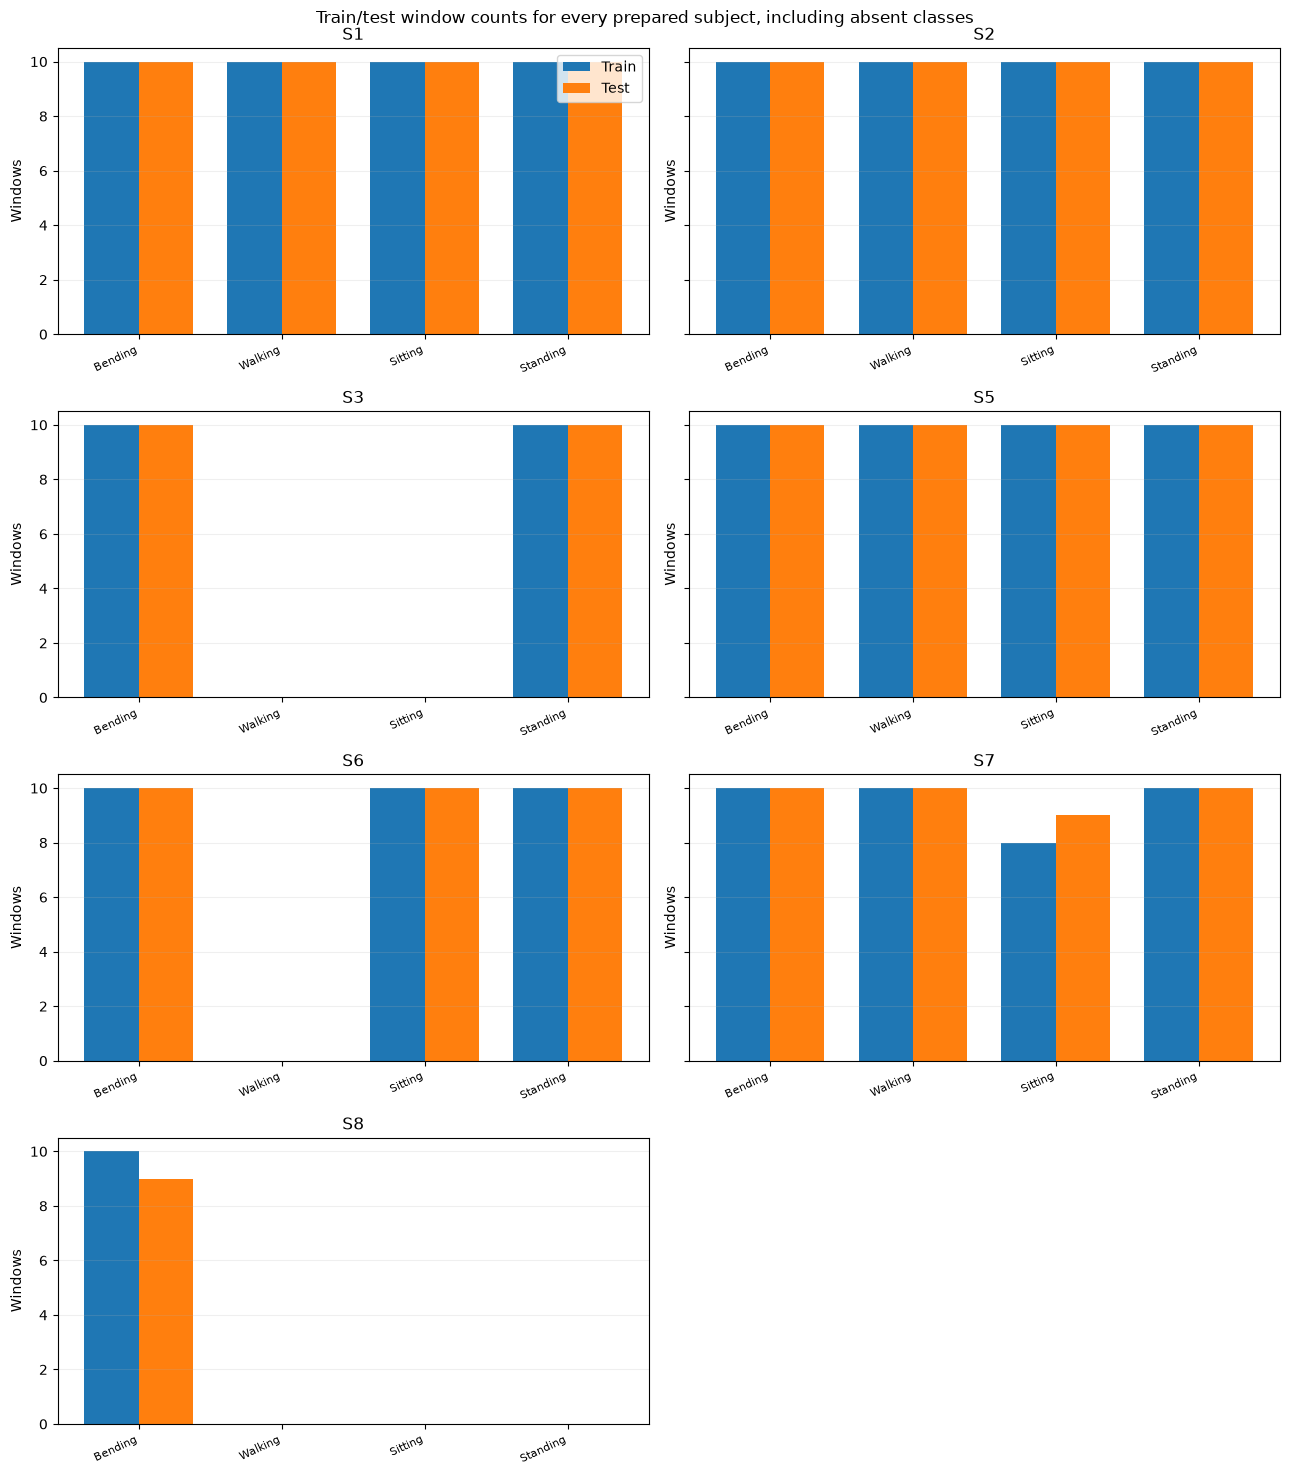

In [8]:
# Extend class-count visualization to every prepared subject, including partial class sets.
subject_names = list(SUBJECT_DATASETS)
fig, axes = plt.subplots(4, 2, figsize=(13, 15), sharey=True)
for axis, subject in zip(axes.flat, subject_names):
    dataset = SUBJECT_DATASETS[subject]
    train_counts = Counter(dataset['y_train'].tolist())
    test_counts = Counter(dataset['y_test'].tolist())
    positions = np.arange(len(CLASS_IDS))
    width = 0.38
    axis.bar(positions - width / 2, [train_counts[int(c)] for c in CLASS_IDS], width, label='Train')
    axis.bar(positions + width / 2, [test_counts[int(c)] for c in CLASS_IDS], width, label='Test')
    axis.set_xticks(positions, [CLASS_NAMES[int(c)] for c in CLASS_IDS], rotation=25, ha='right', fontsize=8)
    axis.set_title(subject)
    axis.set_ylabel('Windows')
    axis.grid(axis='y', alpha=0.2)
for axis in axes.flat[len(subject_names):]:
    axis.set_visible(False)
axes.flat[0].legend()
fig.suptitle('Train/test window counts for every prepared subject, including absent classes')
fig.tight_layout()
fig.savefig(FIGURE_ROOT / 'class_counts_all_prepared_subjects.png', dpi=170, bbox_inches='tight')
plt.show()

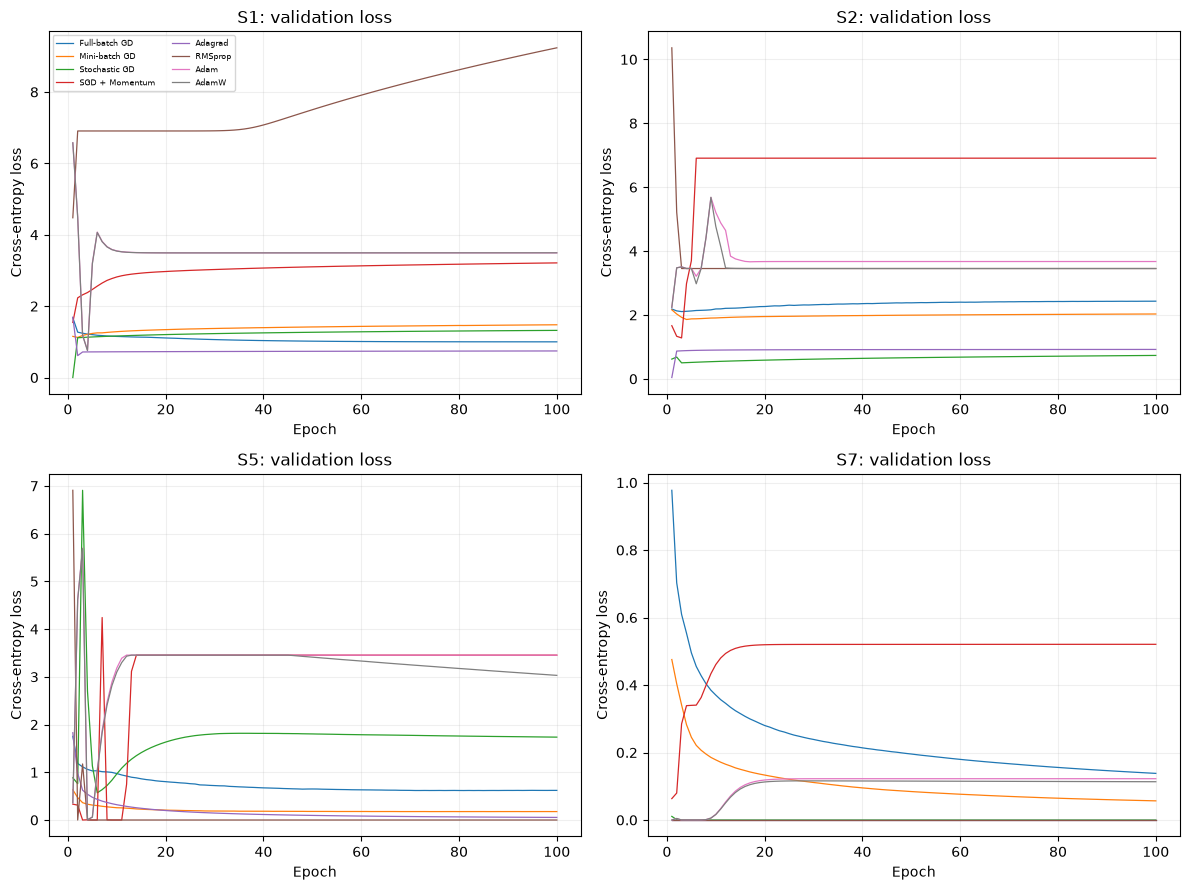

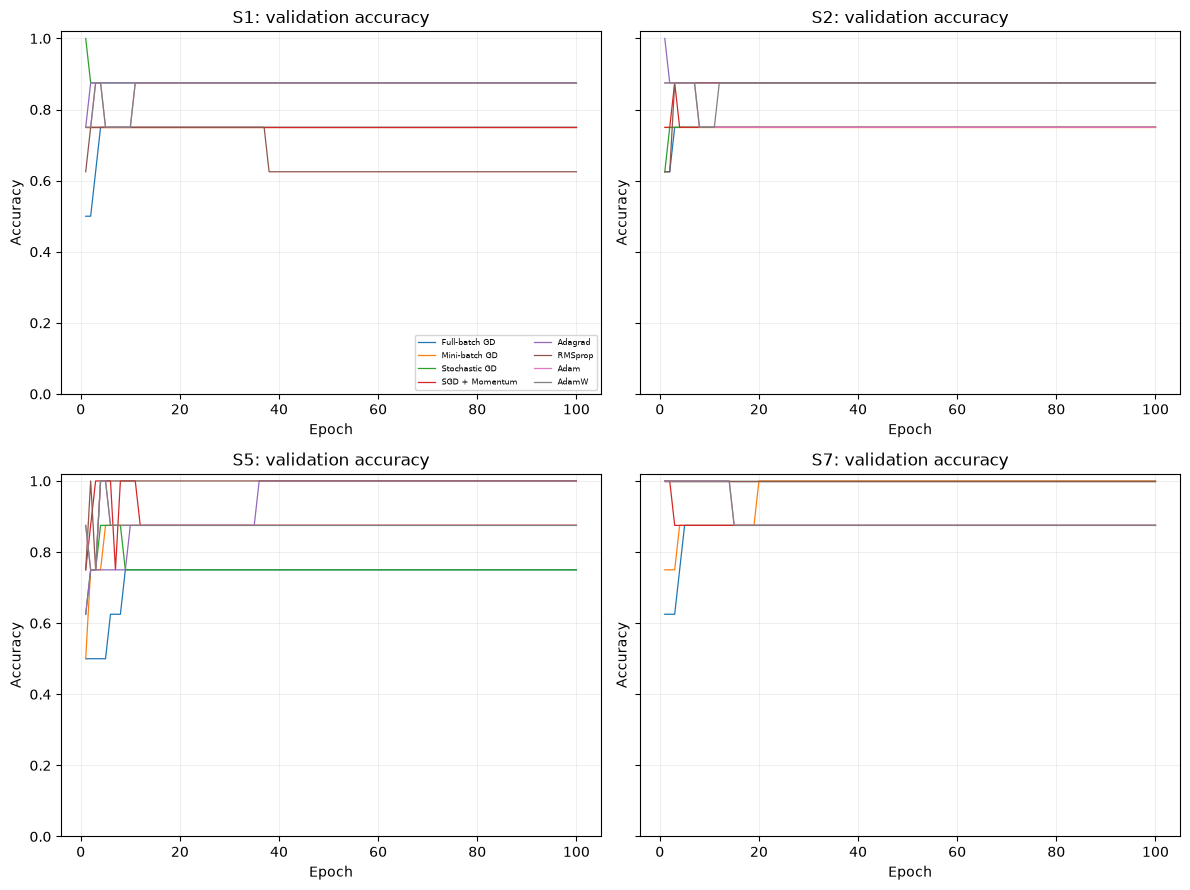

In [9]:
# Compact report figures: validation loss and accuracy by epoch for all eligible subjects.
report_loss_figure, loss_axes = plt.subplots(2, 2, figsize=(12, 9))
report_accuracy_figure, accuracy_axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True)
for loss_axis, accuracy_axis, subject in zip(loss_axes.flat, accuracy_axes.flat, MODEL_DATA):
    for optimizer_name in optimizer_names:
        history = experiment_histories[(subject, optimizer_name)]
        loss_axis.plot(history['epoch'], history['validation_loss'], label=optimizer_name, linewidth=0.9)
        accuracy_axis.plot(history['epoch'], history['validation_accuracy'], label=optimizer_name, linewidth=0.9)
    loss_axis.set_title(f'{subject}: validation loss')
    loss_axis.set_xlabel('Epoch')
    loss_axis.set_ylabel('Cross-entropy loss')
    loss_axis.grid(alpha=0.2)
    accuracy_axis.set_title(f'{subject}: validation accuracy')
    accuracy_axis.set_xlabel('Epoch')
    accuracy_axis.set_ylabel('Accuracy')
    accuracy_axis.set_ylim(0, 1.02)
    accuracy_axis.grid(alpha=0.2)
loss_axes.flat[0].legend(fontsize=6, ncol=2)
accuracy_axes.flat[0].legend(fontsize=6, ncol=2, loc='lower right')
report_loss_figure.tight_layout()
report_accuracy_figure.tight_layout()
report_loss_figure.savefig(FIGURE_ROOT / 'report_validation_loss_all_subjects.png', dpi=170, bbox_inches='tight')
report_accuracy_figure.savefig(FIGURE_ROOT / 'report_validation_accuracy_all_subjects.png', dpi=170, bbox_inches='tight')
plt.show()

In [10]:
import textwrap
from matplotlib.backends.backend_pdf import PdfPages


def save_text_page(pdf, title, sections):
    page = plt.figure(figsize=(8.27, 11.69))
    page.text(0.07, 0.96, title, fontsize=17, weight='bold', va='top')
    y = 0.91
    for heading, text in sections:
        page.text(0.08, y, heading, fontsize=11, weight='bold', va='top')
        y -= 0.033
        wrapped = textwrap.fill(text, width=95)
        page.text(0.08, y, wrapped, fontsize=8.6, va='top', linespacing=1.3)
        y -= 0.022 * (wrapped.count('\n') + 1) + 0.03
    pdf.savefig(page, bbox_inches='tight')
    plt.close(page)


def add_plot_page(pdf, title, figure_path, caption):
    page = plt.figure(figsize=(8.27, 11.69))
    page.text(0.07, 0.96, title, fontsize=16, weight='bold', va='top')
    axis = page.add_axes([0.05, 0.14, 0.90, 0.78])
    axis.imshow(plt.imread(figure_path))
    axis.set_aspect('auto')
    axis.axis('off')
    page.text(0.07, 0.08, textwrap.fill(caption, width=110), fontsize=8.5, va='bottom')
    pdf.savefig(page, bbox_inches='tight')
    plt.close(page)

print('Report helper functions are ready.')

Report helper functions are ready.


In [ ]:
from matplotlib.backends.backend_pdf import PdfPages

FINAL_REPORT_PATH = EXPERIMENT_DIR / 'CogAge_all_subjects_optimizer_report_6page.pdf'
report_results = experiment_results.copy()
report_results['best_validation_loss'] = report_results['best_validation_loss'].map(lambda value: f'{value:.3f}')
report_results['test_accuracy'] = report_results['test_accuracy'].map(lambda value: f'{value:.3f}')
report_results['test_macro_f1'] = report_results['test_macro_f1'].map(lambda value: f'{value:.3f}')
report_results['training_seconds'] = report_results['training_seconds'].map(lambda value: f'{value:.2f}')
report_results['total_updates'] = report_results['total_updates'].map(lambda value: f'{int(value):,}')

with PdfPages(FINAL_REPORT_PATH) as pdf:
    page = plt.figure(figsize=(8.27, 11.69))
    page.text(0.07, 0.96, 'CogAge all-subject optimizer comparison', fontsize=17, weight='bold', va='top')
    intro_sections = [
        ('Classes and availability', 'Bending=0, Walking=1, Sitting=2, Standing=3. Four-class optimizer runs include S1, S2, S5, and S7. S3, S6, and S8 are previewed but excluded because class pairs are missing; S4 has no original test folders.'),
        ('Data and splits', 'Each window is 128 x 33. Original _1_extracted folders supply train; _2_extracted folders supply held-out test. Validation Events are selected only from each subject\'s original train windows, with Event groups kept intact. A new StandardScaler is fitted only on model-training windows. No class balancing is used.'),
        ('Network and fixed settings', f'NumPy MLP: {INPUT_DIM} -> 32 -> 16 -> 4 logits, ReLU hidden layers, {PARAMETER_COUNT:,} parameters, stable sparse cross-entropy. Seed {EXPERIMENT_SEED}; 100 epochs; LR {LEARNING_RATE}; mini-batch 8; momentum 0.9; RMSprop decay 0.99; Adam betas (0.9,0.999); AdamW weight decay 0.01.'),
        ('Optimizer updates', 'Full-batch GD updates once per epoch; mini-batch once per batch; stochastic GD once per example. Momentum accumulates velocity; Adagrad accumulates squared gradients; RMSprop uses an exponential squared-gradient average; Adam uses first and second moments; AdamW decouples weight decay. Compare update counts and elapsed time, not epochs alone.'),
        ('Limits and disclosure', 'Few Events make validation estimates noisy. These are within-subject results, not participant-independent generalization. The raw-file audit, interpolation/removal counts, and discarded windows are in each subject dataset folder. GitHub Copilot assisted with drafting/debugging; verify and disclose as required.'),
    ]
    y = 0.91
    for heading, text in intro_sections:
        page.text(0.08, y, heading, fontsize=9.0, weight='bold', va='top')
        y -= 0.024
        wrapped = textwrap.fill(text, width=108)
        page.text(0.08, y, wrapped, fontsize=7.0, va='top', linespacing=1.15)
        y -= 0.017 * (wrapped.count('\n') + 1) + 0.018

    conclusion_rows = []
    for subject in MODEL_DATA:
        subject_results = experiment_results[experiment_results['subject'] == subject]
        best_val = subject_results.loc[subject_results['best_validation_loss'].idxmin()]
        best_f1 = subject_results.loc[subject_results['test_macro_f1'].idxmax()]
        conclusion_rows.append(
            f"{subject}: lowest validation loss {best_val['optimizer']} ({best_val['best_validation_loss']:.3f}, epoch {int(best_val['best_epoch'])}); "
            f"highest test macro F1 {best_f1['optimizer']} ({best_f1['test_macro_f1']:.3f})."
        )
    page.text(0.08, 0.415, textwrap.fill('Observed results: ' + ' '.join(conclusion_rows), width=110), fontsize=6.8, va='top')

    table_axis = page.add_axes([0.055, 0.035, 0.90, 0.35])
    table_axis.axis('off')
    result_table = table_axis.table(
        cellText=report_results[['subject', 'optimizer', 'best_validation_loss', 'best_epoch', 'test_accuracy', 'test_macro_f1', 'training_seconds', 'total_updates']].values.tolist(),
        colLabels=['Subject', 'Optimizer', 'Val loss', 'Epoch', 'Test acc.', 'Macro F1', 'Seconds', 'Updates'],
        cellLoc='center', colLoc='center', loc='center',
        colWidths=[0.09, 0.20, 0.10, 0.07, 0.10, 0.10, 0.10, 0.12],
    )
    result_table.auto_set_font_size(False)
    result_table.set_fontsize(5.6)
    result_table.scale(1, 1.12)
    pdf.savefig(page, bbox_inches='tight')
    plt.close(page)

    for title, image_path, caption in [
        ('Validation loss curves', FIGURE_ROOT / 'report_validation_loss_all_subjects.png', 'Figure 1. Validation loss by epoch for all eight optimizers, shown separately for S1, S2, S5 and S7.'),
        ('Validation accuracy curves', FIGURE_ROOT / 'report_validation_accuracy_all_subjects.png', 'Figure 2. Validation accuracy by epoch. Small validation sets make each misclassification consequential.'),
        ('Convergence and test metrics', FIGURE_ROOT / 'report_convergence_and_test_metrics.png', 'Figure 3. Validation loss versus cumulative updates and held-out test accuracy/macro F1 by subject. Update counts differ by batch size.'),
    ]:
        page = plt.figure(figsize=(8.27, 11.69))
        page.text(0.06, 0.96, title, fontsize=16, weight='bold', va='top')
        axis = page.add_axes([0.04, 0.15, 0.92, 0.76])
        axis.imshow(plt.imread(image_path))
        axis.set_aspect('auto')
        axis.axis('off')
        page.text(0.06, 0.07, textwrap.fill(caption, width=110), fontsize=8, va='bottom')
        pdf.savefig(page, bbox_inches='tight')
        plt.close(page)

    for subject_pair in (('S1', 'S2'), ('S5', 'S7')):
        page = plt.figure(figsize=(11.69, 8.27))
        page.text(0.04, 0.965, f"Held-out test confusion matrices: {', '.join(subject_pair)}", fontsize=15, weight='bold', va='top')
        for index, subject in enumerate(subject_pair):
            axis = page.add_axes([0.02 + index * 0.49, 0.07, 0.47, 0.84])
            axis.imshow(plt.imread(FIGURE_ROOT / subject / 'confusion_matrices.png'))
            axis.set_title(subject, fontsize=11)
            axis.axis('off')
        page.text(0.04, 0.025, 'Each matrix is 4 x 4; rows=true, columns=predicted; labels: Bending, Walking, Sitting, Standing.', fontsize=8, va='bottom')
        pdf.savefig(page, bbox_inches='tight')
        plt.close(page)

print('Final six-page report:', FINAL_REPORT_PATH.resolve())
print('Experiment directory:', EXPERIMENT_DIR.resolve())